# Trabajo práctico integrador - Grupo 4

El comitente posee un sistema desarrollado sobre una web, con un carrusel que muestra a los usuarios juegos que pueden interesarle al cliente. Actualmente, los juegos mostrados al cliente se eligen de manera aleatoria.
<br><br>
Este es el proceso de minería de datos para obtener el sistema recomendador que reemplazara las recomendaciones aleatorias que actualmente tiene el sistema. Para la realización del proceso, utilizaremos la metodología CRISP-DM. Seguiremos sus fases y actividades genéricas siempre que consideremos que sean requeridas, y en caso de saltear alguna justificaremos por qué no la incluimos.

## Fase 1 - Entendimiento del negocio

Nuestro objetivo en esta fase es entender el problema de negocio y traducirlo a un problema de minería de datos.

### Actividad 1.1: Determinar objetivos de negocio

El objetivo de negocio es aumentar las ganancias por ventas de videojuegos en un 10% para el año 2026 (comparandolo con las ventas del 2025).

### Actividad 1.2: Evaluar la situacion actual

El caso a tratar es sobre una plataforma virtual de venta de videojuegos. Contamos con la siguiente información del sistema:
* Hay un total de 100 juegos en venta.
* El sistema actual de recomendación muestra artículos aleatorios.
* No se cuenta con una base de datos (no hay usuarios, ni preferencias, ni ítems).
<br><br>

Y como supuestos del problema:
* No se agregarán nuevos ítems al carrusel.
* Cada usuario suele comprar entre 7 y 8 con una varianza de 10 juegos.

### Actividad: 1.3 Determinar los objetivos de la minería de datos

El objetivo de la minería de datos es crear un sistema recomendador capaz de recomendar k videojuegos a un usuario determinado, de tal forma que las recomendaciones cumplan con los siguientes requisitos:
* Novedad: El sistema recomendador no debe recomendar videojuegos ya puntuados por el usuario.
* Diversidad: La diversidad de las recomendaciones generadas por el sistema recomendador no deberá ser inferior en más de un 20% a la diversidad obtenida mediante un sistema de recomendaciones aleatorias.
* Serendipia: Al menos un 15% de los artículos recomendados deben ser inesperados para el usuario.
* Relevancia: Al menos un 60% de los artículos recomendados deberán ser relevantes para el usuario.

Además de recomendar k videojuegos a un usuario cumpliendo los requisitos anteriores, el sistema recomendador debe ser capaz de generar esas k recomendaciones en un tiempo menor a un segundo.

### Actividad: 1.4: Elaborar un plan de proyecto

Hasta ahora planteamos los objetivos de negocio (lo que quieren los stakeholders), analizamos la situación actual y determinamos qué queremos lograr en el proceso de minería de datos. A partir de ahora, el plan es el siguiente:
1. **Entender los datos:** Coincide con la fase 2 de CRISP-DM. Buscamos:
    * Familiarizarnos con el dataset.
    * Analizar cada atributo (tipo, semántica, rango).
    * Detectar anomalías
    * Verificar la calidad de los datos.
2. **Preparar los datos para el modelo:** Coincide con la fase 3 de CRISP-DM. Buscamos:
    * Asegurar la calidad de los datos.
    * Preparar esos datos para el modelado.
3. **Modelar el sistema recomendador:** Coincide con la fase 4 de CRISP-DM. Buscamos:
    * Seleccionar la técnica de modelado adecuada basándonos en la información obtenida en todo el proceso anterior.
    * Definir métricas de evaluación de los sistemas recomendadores candidatos.
    * Construir los sistemas recomendadores.
    * Evaluarlos según los criterios definidos anteriormente.
    * Elegir el sistema recomendador que más se ajuste a esos criterios.
4. **Evaluar el modelo:** Coincide con la fase 5 de CRISP-DM. Tenemos que verificar que el sistema recomendador elegido cumpla con los objetivos de la minería de datos planteados en la fase 1.
5. **Desplegar el modelo:** Coincide con la fase 6 de CRISP-DM. Consiste en definir cómo implementaremos el sistema recomendador y definir un plan de seguimiento del mismo.
<br>
<br>

Cabe aclarar que en todo momento tendremos en cuenta que CRISP-DM es una metodología iterativa, y por ende contempla (y casi que exige) que no se siga una secuencia lineal entre fases. A lo largo del proceso volveremos hacia atrás entre fases y actividades siempre que lo consideremos necesario. El plan solo representa una secuencia ideal de trabajo, que puede ser ajustada o modificada durante el desarrollo del proyecto.

## Fase 2 - Entendimiento de los datos

El objetivo principal de esta fase es familiarizarnos con los datos. Antes de empezar con este proceso, es necesario cargar todas las librerías que utilizaremos a lo largo del trabajo.

In [1]:
"""
# INSTALLADOR DE LIBERÍAS, DESCOMENTA ESTO PARA INSTALAR LAS LIBRERÍAS NECESARIAS PARA EL PROYECTO
!pip install pandas numpy matplotlib seaborn statistics re Levenshtein networkx combinations
"""

# Importar liberías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import seaborn as sns
import statistics
import re
import Levenshtein
import networkx as nx
from itertools import combinations

C:\Users\facun\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Actividad 2.1: Recolección inicial de los de datos

Los datos de los 100 juegos se encuentran en el archivo subido a GitHub database/games.csv, así que procedemos a cargar este archivo en nuestro Jupyter y verificamos si se cargó correctamente

In [ ]:
url = '../database/games.csv'

df = pd.read_csv(url)

df

,id,title,releaseDate,rating,genres,description,platforms,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment,platform_metascores,developer,publisher
0,1300638463,Astro Bot,2024-09-06,E10+,Platformer,When the PS5 mothership is attacked by ASTRO’s...,PlayStation 5,94.0,136,Universal acclaim,91,5575,Universal acclaim,94,Team Asobi,Sony Interactive Entertainment
1,1300501848,Baldur's Gate 3,2023-08-03,M,RPG,"An ancient evil has returned to Baldur's Gate,...","PC,PlayStation 5,Xbox Series X",96.0,112,Universal acclaim,92,20175,Universal acclaim,"96,96,99",Larian Studios Games,Larian Studios Games
2,1300044321,Battlefield 3,2011-10-25,M,"Shooter, Strategy","As bullets whiz by, walls crumble, and explosi...","PC,Xbox 360,PlayStation 3",89.0,61,Generally favorable,77,6240,Generally favorable,"89,84,85",EA DICE,Electronic Arts
3,1300022724,BioShock,2007-08-21,M,Shooter,"Going beyond ""run and gun corridors,"" ""monster...","PC,Xbox 360,PlayStation 3,iOS (iPhone/iPad)",96.0,88,Universal acclaim,88,4067,Generally favorable,"96,96,94,68","Irrational Games,2K Marin","2K Games,Spike"
4,1300287014,Bloodborne,2015-03-24,M,"Action, RPG",Bloodborne is an action RPG in which you hunt ...,PlayStation 4,92.0,100,Universal acclaim,89,14147,Generally favorable,92,From Software,"SCEA,Sony Interactive Entertainment,SCEI,SCEE,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1300108757,Trials Evolution,2012-04-18,E10+,"Simulation, Racing",The follow-up to Trials HD brings the bike-rac...,Xbox 360,90.0,77,Universal acclaim,80,311,Generally favorable,90,"RedLynx,Ubisoft",Microsoft Game Studios
96,1300041127,Uncharted 2: Among Thieves,2009-10-13,T,"Action, Adventure",Fortune hunter Nathan Drake returns in Unchart...,PlayStation 3,96.0,105,Universal acclaim,89,8049,Generally favorable,96,Naughty Dog,"SCEA,SCEI,SCEE,SCE Australia"
97,1300223143,Uncharted 4: A Thief's End,2016-05-10,T,"Action, Adventure","Set 3 years after the events of Uncharted 3, N...",PlayStation 4,93.0,113,Universal acclaim,87,17189,Generally favorable,93,Naughty Dog,"Sony Interactive Entertainment,SCEE,SCE Australia"
98,1300032946,World of Warcraft: Wrath of the Lich King,2008-11-13,T,"RPG, Puzzle/Horror","Players last visited Northrend in ""Warcraft II...",PC,91.0,47,Universal acclaim,82,1492,Generally favorable,91,Blizzard Entertainment,Blizzard Entertainment


Estos datos fueron proporcionados por el stakeholder, el archivo se subió GitHub y ahora lo cargamos en el Jupyter. Está listo para ser tratado en el proceso de minería de datos.

### Actividad 2.2: Descripción de los datos

Necesitamos realizar una descripción detallada de los datos y de sus particularidades.

#### Instancia 2.2.1: Tamaño del dataset, atributos y valores nulos

Utilizamos .info y .info().sum() para conocer la informacion de las columnas del data frame y corroborar que sí tiene 100 juegos en total.

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   100 non-null    int64  
 1   title                100 non-null    str    
 2   releaseDate          100 non-null    str    
 3   rating               95 non-null     str    
 4   genres               100 non-null    str    
 5   description          100 non-null    str    
 6   platforms            100 non-null    str    
 7   metascore            100 non-null    float64
 8   metascore_count      100 non-null    int64  
 9   metascore_sentiment  100 non-null    str    
 10  userscore            100 non-null    int64  
 11  userscore_count      100 non-null    int64  
 12  userscore_sentiment  100 non-null    str    
 13  platform_metascores  100 non-null    str    
 14  developer            100 non-null    str    
 15  publisher            100 non-null    str    
dtypes:

id                     0
title                  0
releaseDate            0
rating                 5
genres                 0
description            0
platforms              0
metascore              0
metascore_count        0
metascore_sentiment    0
userscore              0
userscore_count        0
userscore_sentiment    0
platform_metascores    0
developer              0
publisher              0
dtype: int64

Efectivamente, el dataset contiene 100 elementos. Además, podemos ver que en rating se encuentran 5 datos nulos en la columna "rating", mientras que el resto de columnas no tienen valores nulos. Dejamos pendiente el análisis de estos valores nulos para la actividad 2.4 (verificación de la calidad de los datos).
<br>

Tambien logramos conocer cada uno de los atributos del dataset: <br>
* id
* title
* releaseDate
* rating
* genres
* description
* platforms
* metascore
* metascore_count
* metascore_sentiment
* userscore
* userscore_count
* userscore_sentiment
* platform_metascores
* developer
* publisher

#### Instancia 2.2.2: Análisis del atributo "rating"

Ahora, queremos describir c/atributo y entenderlo. Queremos conocer:
* Su tipo
* Su rango de valores
* Su semántica asociada
* Tener una idea de su distribución estadística

Y ya que estabamos hablando del atributo "rating", empezaremos con este.

In [ ]:
print(df["rating"].dtype)
df["rating"].value_counts()

str


rating
M       35
E       28
T       23
E10+     9
Name: count, dtype: int64

Los valores posibles son:
* M
* T
* E10+
* E

Inicialmente pensabamos que estaba relacionado a la puntuación del juego, pero no tiene mucho sentido con los valores vistos. Investigando qué significan estas letras, encontramos que corresponden al sistema de clasificación por edades de ESRB. Estas clasificaciones se muestran en la página oficial de ESRB: [Guía oficial de clasificaciones ESRB](https://www.esrb.org/ratings-guide/)
<br>
<br>

Significado de c/valor (semántica):
* M (Mature) → 17+ años. Contenido para adultos, puede contener violencia fuerte, lenguaje fuerte, etc.
* T (Teen) → 13+ años. Contenido para adolescentes o adultos, puede haber violencia moderada, lenguaje leve o temas sugestivos.
* E10+ (Everyone 10+) → 10+ años. Algo más de acción o violencia caricaturesca.
* E (Everyone) → Apto para todo público.
<br>
<br>

Este atributo es de tipo ordinal. Sus valores representan categorías de clasificación etaria de los videojuegos. Las categorías no son cuantitativas, pero poseen un orden natural según la edad del usuario. Se trata de categorías, como un atributo nominal, pero al tener un orden, es un atributo ordinal. Además, como solo puede tener un solo valor, es univaluado.
<br>
<br>

Al ser un atributo ordinal, el dominio de "rating" serían las categorías de ESRB ya mencionadas, que ordenados de menor a mayor serían:
1. E (28)
2. E10+ (9)
3. T (23)
4. M (35)

En consecuencia, el rango ordinal del atributo va desde E (menor restricción) hasta M (mayor restricción).
<br>
<br>

En cuánto a la distribución estadística:
* Estamos ante una distribución asimétrica con sesgo negativo. Los juegos de la parte derecha de la clasificación, los superiores, M y T, son muchos más que los de la izquierda, E10+ y E, por lo que está sesgada hacia la izquierda (sesgo negativo).
* La moda es M, los juegos para adultos, con un total de 35 juegos.
* Tenemos 3 clases predominantes, con cantidades bastante similares (E(28), T(23) y M(35)), y una clase con pocos elementos (9). Al ser E10+ una categoría intermedia con baja frecuencia, nos indica que esta clase es la que nos genera asimetría en la distribución, pero en general, los juegos están distribuidos entre todas las categorías etarias.

**Conclusiones del atributo "rating":**
* Tipo: Ordinal univaluado.
* Semántica: Clasificación etaria del juego formato ESRB, E: Todo público, E10+: Mayores de 10, T: Adolescentes mayores de 13, M: Mayores de 17
* Dominio (ordenado): [E, E10+, T, M].
* Distribución estadística: Distribución asimétrica con sesgo negativo, que podría ser simétrica simplificando las categorías E10+ y E en una sola E.

#### Instancia 2.2.3: Análisis del atributo "releaseDate"

Traduciendolo al español, sabemos que la semántica de este atributo es la fecha de lanzamiento del juego (salvo que durante su descripción descubramos algo diferente a esto, mantendremos ésta interpretación). Veamos algunos valores y observemos cómo está codificado el atributo.

In [ ]:
df["releaseDate"].dtype
df["releaseDate"].head(5)

0    2024-09-06
1    2023-08-03
2    2011-10-25
3    2007-08-21
4    2015-03-24
Name: releaseDate, dtype: str

Las fechas están en formato string, pero el tipo de atributo es numérico intervalado-discreto. Es numérico porque es un atributo cuantitativo, es discreto porque entre dos valores no siempre hay un valor (por ejemplo, dos fechas correspondientes a días consecutivos), y es intervalado porque los valores están en una escala ordenada donde las diferencias entre valores tienen significado (podemos calcular cuántos días hay entre dos fechas). Además, es univaluado, pues solo puede tomar un solo valor.
<br>
<br>

Para conocer el rango, pasaremos las fechas codificadas como string a formato date, verificamos que no se haya perdido ninguna fecha por el camino y miramos los máximos y mínimos

In [ ]:
df_datesfixed = df.copy()
df_datesfixed["releaseDate"] = pd.to_datetime(df["releaseDate"], errors="coerce")
print(len(df_datesfixed))
df_datesfixed["releaseDate"].agg(["min","max"])

100


min   2001-07-09
max   2025-09-04
Name: releaseDate, dtype: datetime64[us]

El rango de fechas entonces es [2001-07-09, 2025-19-04].
<br>
<br>

Para darnos una idea de la distribución estadística, utilizaremos descriptores estadísticos. Para ello, nos conviene discretizar las fechas en años, y ahí calculamos la moda, la mediana y el promedio:

In [ ]:
df_dates_as_year = df_datesfixed.copy()
df_dates_as_year["releaseDate"] = pd.to_datetime(df_datesfixed["releaseDate"], errors="coerce").dt.year

# Verifico que el cambio se haya hecho correctamente
print(len(df_dates_as_year))
print("Min:", df_dates_as_year["releaseDate"].min())
print("Max:", df_dates_as_year["releaseDate"].max())

# Calculo el promedio, mediana y moda
promedio = df_dates_as_year["releaseDate"].mean()
mediana = df_dates_as_year["releaseDate"].median()
moda = df_dates_as_year["releaseDate"].mode()[0]
cantidad = df_dates_as_year["releaseDate"].value_counts().iloc[0]

print(f"Promedio: {promedio}")
print(f"Mediana: {mediana}")
print(f"Moda: {moda}, cantidad de juegos en ese año: {cantidad}")

100
Min: 2001
Max: 2025
Promedio: 2014.06
Mediana: 2014.5
Moda: 2010, cantidad de juegos en ese año: 7


Sobre la distribución estadística:
* La distribución parece bastante equilibrada dentro del rango analizado. Esta apenas sesgada hacia la izquierda, mucho menos de lo que se esperaba. Podíamos pensar que, como en los últimos años se han lanzado más juegos que nunca, el promedio, la mediana y la moda iban a estar más sesgados hacia la izquierda, y no es el caso. Aún así, como Promedio (2014.06) < Mediana (2014.5), podemos afirmar que tiene un leve sesgo negativo (hacia la izquierda).
* Podíamos pensar que el juego del 2001 era una "anomalía", pero en cierto modo, que el sesgo hacia los últimos años no sea excesivo, nos discipa de dudas (por el momento, veremos más adelante).
* La moda es el 2010, es el año con más videojuegos lanzados en el dataset.

**Conclusiones del atributo "releaseDate":**
* Tipo: Numérico intervalado-discreto univaluado.
* Semántica: Fecha de lanzamiento del juego.
* Rango: [2001-07-09, 2025-19-04].
* Distribución estadística: Leve sesgo hacia la izquierda (sesgo negativo).

#### Instancia 2.2.4: Semántica y tipo de los atributos "metascore", "metascore_count", "metascore_sentiment", "userscore", "userscore_count", "userscore_sentiment"
Todos estos atributos son similares y están relacionados entre sí. Enseguida veremos porque. Veamos los valores que contienen estos atributos.

In [ ]:
df[["metascore","metascore_count","metascore_sentiment","userscore", "userscore_count","userscore_sentiment"]].head(10)

,metascore,metascore_count,metascore_sentiment,userscore,userscore_count,userscore_sentiment
0,94.0,136,Universal acclaim,91,5575,Universal acclaim
1,96.0,112,Universal acclaim,92,20175,Universal acclaim
2,89.0,61,Generally favorable,77,6240,Generally favorable
3,96.0,88,Universal acclaim,88,4067,Generally favorable
4,92.0,100,Universal acclaim,89,14147,Generally favorable
5,94.0,76,Universal acclaim,87,331,Generally favorable
6,87.0,89,Generally favorable,72,2669,Mixed or average
7,83.0,72,Generally favorable,43,2192,Generally unfavorable
8,82.0,63,Generally favorable,62,2095,Mixed or average
9,77.0,87,Generally favorable,44,2134,Generally unfavorable


Semánticamente, "metascore" es el puntaje promedio que los críticos asignaron al juego en cuestión, "metascore_count" es la cantidad de puntajes tomados para calcular ese promedio, y "metascore_sentiment" es la traducción cualitativa del puntaje numérico que vimos de los criticos, básicamente agrupa los puntajes en rangos y los etiqueta. El rango específico para cada valor de "metascore_sentiment" lo veremos en la actividad 2.3 (exploración de los datos), cuando comparemos "metascore" con "metascore_sentiment".
<br>
<br>

Paralelamente, sucede lo mismo con "userscore", "userscore_count" y "userscore_sentiment". "userscore" se refiere al puntaje promedio de los usuarios, "userscore_count" es la cantidad de puntajes tomados para calcular ese promedio, y "userscore_sentiment" es un adjetivo descriptivo de ese puntaje.
<br>
<br>

Tanto "metascore" como "metascore_count", "userscore" y "userscore_count" son atributos numéricos, pues contienen números que representan cantidades. Son numéricos discretos pues los valores son siempre enteros, y son proporcionados porque no pueden tomar valores negativos. Todos ellos son univaluados, pues solo pueden tomar un valor.
<br>
<br>

Por otro lado, "userscore_sentiment" y "metascore_sentiment" son atributos ordinales, pues son categorías que tienen un orden jerárquico pero no podemos establecer una distancia cuantitativa entre características. Numéricamente si podríamos calcularla porque tenemos el "metascore" o el "userscore", pero si tendríamos solo el sentimiento, verdaderamente no sabemos cuánta diferencia hay entre "Generally favorable" y "Mixed or average". Por eso es ordinal. A su vez es univaluado, solo puede tener un valor a la vez.

#### Instancia 2.2.5: Rango y distribución estadística de los atributos "userscore_sentiment" y "metascore_sentiment"

Ya conociendo la semántica de los 6 atributos anteriores, tenemos que ver los rangos/dominios de c/uno. Empecemos con los rangos de "userscore_sentiment" y "metascore_sentiment"

In [ ]:
sentimientos_metascore = df["metascore_sentiment"].unique().tolist()
sentimientos_userscore = df["userscore_sentiment"].unique().tolist()

print("Valores posibles en metascore_sentiment:")
for sentimiento in sentimientos_metascore:
    print(f"• {sentimiento}")

print("\nValores posibles en userscore_sentiment:")
for sentimiento in sentimientos_userscore:
    print(f"• {sentimiento}")

Valores posibles en metascore_sentiment:
• Universal acclaim
• Generally favorable

Valores posibles en userscore_sentiment:
• Universal acclaim
• Generally favorable
• Mixed or average
• Generally unfavorable


El dominio de "metascore_sentiment", ordenado de mayor a menor, sería:
* Universal acclaim.
* Generally favorable.
<br>
<br>

Mientras que el dominio de "userscore_sentiment", ordenado de mayor a menor, sería:
* Universal acclaim.
* Generally favorable.
* Mixed or average.
* Generally unfavorable.
<br>
<br>

Podemos ver ya con el sentimiento de la puntuación, que los usuarios suelen poner puntuaciones más bajas a los juegos que los críticos. Seguramente podremos corroborar esto con los descriptores básicos de "userscore" y "metascore". Pero primero veamos la distribución estadística de estas categorías.

In [ ]:
porcentajes_metascore = df["metascore_sentiment"].value_counts(normalize=True) * 100
print("Porcentaje de aparición en metascore_sentiment")
for sentimiento, porcentaje in porcentajes_metascore.items():
    print(f"• {sentimiento}: {porcentaje:.2f}%")
    
print('')
porcentajes_userscore = df["userscore_sentiment"].value_counts(normalize=True) * 100
print("Porcentaje de aparición en userscore_sentiment")
for sentimiento, porcentaje in porcentajes_userscore.items():
    print(f"• {sentimiento}: {porcentaje:.2f}%")

Porcentaje de aparición en metascore_sentiment
• Universal acclaim: 68.00%
• Generally favorable: 32.00%

Porcentaje de aparición en userscore_sentiment
• Generally favorable: 76.00%
• Universal acclaim: 13.00%
• Mixed or average: 7.00%
• Generally unfavorable: 4.00%


Distribución estadística "userscore_sentiment":
* Universal acclaim: 13.00%
* Generally favorable: 76.00%
* Mixed or average: 7.00%
* Generally unfavorable: 4.00%
<br>
<br>

Distribución estadística "metascore_sentiment":
* Universal acclaim: 68.00%
* Generally favorable: 32.00%
<br>
<br>

Con estas distribuciones podemos ver que "metascore_sentiment" no nos dice mucho sobre el juego. Parece que a los críticos les gustan todos los juegos del dataset, y aclaman a una gran parte de ellos. Los usuarios parece que tienen puntajes más realistas, o por lo menos más distribuidos, aunque siguen percibiendo los juegos positivamente en su gran mayoría. 
<br>
<br>

Respecto a "userscore_sentiment", es una distribución asimétrica sesgada hacia la izquierda, puesto que los valores están concentrados en la derecha de la distribución, ya sea aclamados por los usuarios o simplemente con opiniones positivas.

**Conclusiones del atributo "metascore_sentiment":**
* Tipo: Ordinal univaluado.
* Semántica: Etiqueta cualitativa que resume el consenso de la crítica especializada sobre la calidad del juego.
* Dominio: [Generally favorable, Universal acclaim]
* Distribución estadística: Muchos de ellos son aclamados universalmente (68%) por la crítica y una porción considerable (32%) son valorados positivamente pero no aclamados.

**Conclusiones del atributo "userscore_sentiment":**
* Tipo: Ordinal univaluado
* Semántica: Etiqueta cualitativa que resume el consenso y la percepción de la comunidad de jugadores sobre el juego.
* Dominio: [Universal acclaim, Generally favorable, Mixed or average, Generally unfavorable]
* Distribución estadística: Sesgada negativamente.

#### Instancia 2.2.6: Rango y distribución estadística de los atributos "metascore_count" y "userscore_count"

Repasando un poco su semántica, estos atributos cuentan la cantidad de críticos ("metascore_count") y "usuarios" ("userscore_count") que puntuaron el juego y componen el puntaje general del mismo ("metascore" para "metascore_count" y "userscore" para "userscore_count"). Ambos pueden actuar como un intervalo de confianza, a mayor cantidad de reseñas, más representativo y fiable es el puntaje promedio del juego. También pueden ser buenos indicadores de popularidad, ya que si un juego tiene tantas puntuaciones realizadas, es porque es conocido y muy jugado, independientemente de no tenga puntuación tan alta.
<br>
<br>

Ahora sí, vamos con el rango. Entendiendo la semántica, el dominio de valores serían los números enteros positivos, pero podemos acotar un poco ese rango observando los valores de nuestro dataset.

In [ ]:
min_meta = df["metascore_count"].min()
max_meta = df["metascore_count"].max()

min_user = df["userscore_count"].min()
max_user = df["userscore_count"].max()

print("Atributo metascore_count")
print("Mínimo:", min_meta)
print("Máximo:", max_meta)

print('')
print("Atributo userscore_count")
print("Mínimo:", min_user)
print("Máximo:", max_user)

Atributo metascore_count
Mínimo: 34
Máximo: 150

Atributo userscore_count
Mínimo: 77
Máximo: 166719


Rango "metascore_count": [34, 150]
<br>
Rango "userscore_count": [77, 166719]
<br>

No podemos concluir demasiado a partir de estos rangos, solo podemos empezar a pensar que hay muchos más usuarios que puntúan los juegos respecto a los críticos que los puntúan, lo cuál es totalmente esperable. Confirmaremos esto mediante descriptores estadísticos.

In [ ]:
media = df["metascore_count"].mean()
mediana = df["metascore_count"].median()
desviacion = df["metascore_count"].std()

print("Estadísticas de metascore_count")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

media = df["userscore_count"].mean()
mediana = df["userscore_count"].median()
desviacion = df["userscore_count"].std()

print('')
print("Estadísticas de userscore_count")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

Estadísticas de metascore_count
Media: 87.62
Mediana: 85.00
Desviación Estándar: 25.61

Estadísticas de userscore_count
Media: 6487.45
Mediana: 2568.00
Desviación Estándar: 17481.27


Descriptores estadísticos de "metascore_count":
* Media: 87.62
* Mediana: 85
* Desviacion Estandar: 25.61
<br>
<br>

Descriptores estadísticos de "userscore_count":
* Media: 6487.45
* Mediana: 2568.00
* Desviacion Estandar: 17481.27
<br>
<br>

Decidimos no utilizar la moda ya que no tiene mucho sentido teniendo tantos valores discretos posibles. Podríamos discretizar, pero creemos que con la media y la mediana alcanza. La varianza tampoco la incluimos dado a que no es tan interpretable como la desviación estándar.
<br>

Respecto a los valores hallados, se corrobora lo que esperabamos, la mediana y el promedio nos muestran que la mayoría de juegos son puntuados por muchos más usuarios que por críticos. En "metascore_count", la media y mediana son similares y están bastante centradas dentro del rango, lo que nos hace pensar más en una distribución simétrica. Pero también es cierto que Media (87.62) > Mediana (85) por lo que puede considerarse levemente sesgada hacia la derecha, lo que también hace sentido con que los valores de la Media y la Mediana están más cerca de la cota inferior del rango (34) que de la cota superior (150). La desviación estándar (25.73) es moderada para el rango en el que se mueven los valores.
<br>
<br>

A diferencia de las críticas profesionales, el atributo "userscore_count" muestra una distribución asimétrica. Hay una grandísima diferencia entre la mediana y el promedio. Esto indica que hay algunos juegos con muchísimas reseñas de usuario que están sesgando el promedio y haciendo que parezca más grande, pero la mediana nos muestra que ese promedio no es representativo del dataset. Como Mediana (2568.00) < Promedio (6487.45), la distribución está sesgada positivamente (hacia la derecha). La desviación estándar (17481.27) también es altísima, confirmandonos que hay un grupo reducido de juegos hiperpopulares que acumulan reseñas y el resto tiene muchas menos.

**Conclusiones del atributo "metascore_count":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Cantidad de reseñas de críticos profesionales usadas para el promedio del puntaje del juego "userscore".
* Rango: [34, 150].
* Distribución estadística: Leve asimetría positiva con dispersión moderada.

**Conclusiones del atributo "userscore_count":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Cantidad de reseñas de usuarios utilizadas para el promedio del puntaje del juego "userscore".
* Rango: [77, 166719].
* Distribución estadística: Sesgo hacia la derecha (positivo) con alta dispersión.

#### Instancia 2.2.7: Rango y distribución estadística de los atributos "userscore" y "metascore"

In [ ]:
min_meta = df["metascore"].min()
max_meta = df["metascore"].max()

min_user = df["userscore"].min()
max_user = df["userscore"].max()

print("Atributo metascore")
print("Mínimo:", min_meta)
print("Máximo:", max_meta)

print('')
print("Atributo userscore")
print("Mínimo:", min_user)
print("Máximo:", max_user)

Atributo metascore
Mínimo: 77.0
Máximo: 98.0

Atributo userscore
Mínimo: 26
Máximo: 95


Rango "metascore": [77, 98]
<br>
Rango "userscore": [25, 95]
<br>

Confirmamos lo que ya sospechabamos observando las categorías de "userscore_sentiment" y "metascore_sentiment". El rango en el que se mueve "metascore" es mucho más pequeño que el rango de "userscore". Puede ser que los usuarios tiendan a menospreciar juegos que no sean de su agrado, mientras que los críticos se mantienen objetivos y le encuentran lo positivo al juego para terminar dandole un buen puntaje.
<br>
<br>

Continuemos con la distribución estadística:

In [ ]:
media = df["metascore"].mean()
mediana = df["metascore"].median()
desviacion = df["metascore"].std()

print("Estadísticas de metascore")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

media = df["userscore"].mean()
mediana = df["userscore"].median()
desviacion = df["userscore"].std()

print('')
print("Estadísticas de userscore")
print(f"Media: {media:.2f}")
print(f"Mediana: {mediana:.2f}")
print(f"Desviación Estándar: {desviacion:.2f}")

Estadísticas de metascore
Media: 91.17
Mediana: 92.00
Desviación Estándar: 3.98

Estadísticas de userscore
Media: 82.07
Mediana: 85.00
Desviación Estándar: 11.26


Al igual que con "userscore_count" y "metascore_count", no calcularemos la moda ni la varianza. La moda carece de sentido con tantos valores discretos y discretizar sería lo que ya se hizo en los atributos "userscore_sentiment" y "metascore_sentiment". Y la varianza es poco interpretable respecto de la desviación estándar, que es el descriptor que utilizaremos en su lugar.
<br>
<br>

Descriptores estadísticos de "metascore":
* Media: 91.17
* Mediana: 92
* Desviacion Estandar: 3.98
<br>
<br>

Descriptores estadísticos de "userscore":
* Media: 82.07
* Mediana: 85.00
* Desviacion Estandar: 11.26
<br>
<br>

Con los descriptores confirmamos lo que ya se veía en los rangos, los puntajes de los críticos suelen ser un poco más altos que los puntajes de los usuarios. Además, como los puntajes de los críticos tienen menor desviación estándar que los de los usuarios, podemos deducir que los críticos son más consistentes con sus puntajes, mientras que los usuarios presentan opiniones más dispersas. 
<br>
<br>

La distribución de "metascore" es asimétrica hacia la izquierda, porque Mediana (92) > Promedio (92) y además están más cerca de la cota superior del rango que de la cota inferior. Por su parte, "userscore" presenta un sesgo aún más marcado hacia la izquierda (negativo), porque Mediana (85.00) > Promedio (82.00) y estamos mucho más cerca de la cota superior que de la inferior.

**Conclusiones del atributo "metascore":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Promedio del puntaje de reseñas de críticos al juego.
* Rango: [77, 98].
* Distribución estadística: Leve asimetría negativa con baja dispersión.

**Conclusiones del atributo "userscore":**
* Tipo: Numérico discreto-proporcionado univaluado.
* Semántica: Promedio del puntaje de reseñas de usuarios al juego.
* Rango: [25, 95].
* Distribución estadística: Sesgo hacia la izquierda (negativo) con dispersión moderada.

#### Instancia 2.2.8: Análisis de los atributos "genres"

Primero veamos qué valores contiene el atributo "genres"

In [ ]:
df["genres"].head(10)

0                          Platformer
1                                 RPG
2                   Shooter, Strategy
3                             Shooter
4                         Action, RPG
5                              Racing
6                   Shooter, Strategy
7    Shooter, Strategy, Puzzle/Horror
8    Shooter, Strategy, Puzzle/Horror
9    Shooter, Strategy, Puzzle/Horror
Name: genres, dtype: str

Semánticamente, contiene una lista de los géneros a los que pertenece el juego en cuestión. Es un atributo de tipo nominal, pues está formado por categorías que no tienen un orden específico ni distancia entre ellas. Además es multivaluado, puede tomar varios valores simultáneamente.
<br>
<br>

Veamos ahora entonces el dominio de valores posibles de este atributo (o géneros posibles), y de paso cuántos juegos tiene c/género:

In [ ]:
generos_expandidos = df['genres'].str.split(',').explode().str.strip()

conteo_generos = generos_expandidos.value_counts()

for genero, cantidad in conteo_generos.items():
    print(f"{genero}: {cantidad}")

Platformer: 16
RPG: 16
Shooter: 16
Strategy: 16
Action: 16
Racing: 16
Puzzle/Horror: 16
Sports: 16
Simulation: 16
Adventure: 16


Entonces, el juego pertenece a uno o más de estos géneros:
* Platformer (16)
* RPG (16)
* Shooter (16)
* Strategy (16)
* Action (16)
* Racing (16)
* Puzzle/Horror (16)
* Sports (16)
* Simulation (16)
* Adventure (16)
<br>
<br>

Otra observación es que algunos juegos tienen 1 género asociado y otros tienen 2 géneros por lo que vemos en los primeros datos. Para confirmar si solo puede tener hasta 2 géneros y además, cuántos géneros suele tener c/juego, ejecutaremos el siguiente código:

In [ ]:
df["genres"].str.split(",").str.len().value_counts()

genres
1    47
2    46
3     7
Name: count, dtype: int64

Hay 47 juegos que tienen un sólo género, 46 juegos que tienen dos géneros y 3 juegos que tienen tres géneros
<br>
<br>

Además, pasándo a la distribución estadística, todos los 10 géneros aparecen 16 veces. Es una distribución uniforme, todas las categorías tienen la misma frecuencia. Es multimodal porque no hay una moda única, hay 10 modas que serían los 10 géneros. Ahora también queremos ver el peso que tiene c/género en el dataset, ya que no es lo mismo si un género aparece muchas veces sólo (va a tener mucho peso en ese juego) que si aparece junto a otros géneros (tendrá menos peso). Recorremos la lista de videojuegos observando su/s géneros. Si tiene un sólo género, ese género suma 1, si tiene dos géneros, c/género suma 0.5, y si tiene tres géneros, c/género suma 0.3333.

In [ ]:
genre_weights = {}

for genres in df["genres"]:
    genre_list = [g.strip() for g in genres.split(",")]
    k = len(genre_list)
    weight = 1 / k
    
    for g in genre_list:
        if g not in genre_weights:
            genre_weights[g] = 0
        genre_weights[g] += weight

# Mostrar resultados ordenados
for g, w in sorted(genre_weights.items(), key=lambda x: x[1], reverse=True):
    print(g, round(w, 3))

Platformer 13.5
RPG 12.833
Sports 12.167
Racing 10.5
Shooter 9.833
Strategy 9.833
Adventure 8.5
Action 8.0
Simulation 7.667
Puzzle/Horror 7.167


Podemos ver que los géneros Platformer, RPG y Sports suelen aparecer sólos en el dataset, lo que indica que tienen mayor peso en el juego, mientras que otros géneros como Adventure, Action, Simulation y Puzzle/Horror suelen aparecer acompañados, por lo que tienen menor peso en ese dataset.

**Conclusiones del atributo "genres":**
* Tipo: Nominal multivaluado.
* Semántica: Géneros a los que pertenece el juego.
* Dominio: [Platformer, RPG, Shooter, Strategy, Action, Racing, Puzzle/Horror, Sports, Similation, Adventure].
* Distribución estadística: Distribución uniforme. 

#### Instancia 2.2.9: Análisis de los atributos "platforms"

Veamos el atributo "platforms"

In [ ]:
df[["platforms"]].head(10)

,platforms
0,PlayStation 5
1,"PC,PlayStation 5,Xbox Series X"
2,"PC,Xbox 360,PlayStation 3"
3,"PC,Xbox 360,PlayStation 3,iOS (iPhone/iPad)"
4,PlayStation 4
5,"PlayStation 2,Xbox"
6,"PC,PlayStation 3,Xbox 360,Wii,DS"
7,"PlayStation 4,Xbox One,PC"
8,"Xbox Series X,PlayStation 5,PC"
9,"PlayStation 4,Xbox One,PC"


El atributo contiene las plataformas para las que el juego está disponible (esa es la semántica). Veamos cuáles son las plataformas disponibles y cuántos juegos tiene cada plataforma

In [ ]:
df["platforms"].str.split(",").explode().value_counts()

platforms
PC                   57
Xbox 360             23
Nintendo Switch      23
PlayStation 3        21
PlayStation 4        18
PlayStation 5        17
Xbox One             16
Xbox Series X        11
Wii                  10
PlayStation 2         9
Xbox                  7
iOS (iPhone/iPad)     5
DS                    3
Nintendo Switch 2     3
Wii U                 3
GameCube              3
PSP                   2
3DS                   2
Game Boy Advance      2
PlayStation           1
Name: count, dtype: int64

Entonces, el juego puede jugarse en una o más de estas plataformas:
* PC (57)
* Xbox 360 (23)
* Nintendo Switch (23)
* PlayStation 3 (21)
* PlayStation 4 (18)
* PlayStation 5 (17)
* Xbox One (16)
* Xbox Series X (11)
* Wii (10)
* PlayStation 2 (9)
* Xbox (7)
* iOS (iPhone/iPad) (5)
* DS (3)
* Nintendo Switch 2 (3)
* Wii U (3)
* GameCube (3)
* PSP (2)
* 3DS (2)
* Game Boy Advance (2)
* PlayStation (1)

Este listado de valores posibles es el dominio del atributo. Es un atributo de tipo nominal, pues está formado por categorías que no tienen un orden específico ni distancia entre ellas. Además es multivaluado, puede tomar varios valores simultáneamente.
<br>
<br>

Estadísticamente:
* La mitad de los juegos son de PC
* 1/4 de los juegos se pueden jugar en alguna PlayStation, en alguna variante de Nintendo Switch o en alguna Xbox
* Solo una pequeña porción de juegos admiten otras plataformas además de las mencionadas (Wii, iOS, etc.)

**Conclusiones del atributo "platforms":**
* Tipo: Nominal multivaluado.
* Semántica: Plataformas para las que el juego está disponible.
* Dominio: [PC, Xbox 360, Nintendo Switch, PlayStation 3, PlayStation 4, PlayStation 5, Xbox One, Xbox Series X, Wii, PlayStation 2, Xbox, iOS (iPhone/iPad), DS, Nintendo Switch 2, Wii U, GameCube, PSP, 3DS, Game Boy Advance, PlayStation]
* Distribución estadística: La mitad de PC, algunos de Xbox/PlayStation/Nintendo, muy poquitos disponibles en otras plataformas.

#### Instancia 2.2.10: Análisis del atributo "platforms_metascore"

Empecemos por observar los valores que contiene este atributo junto con la columna "platforms"

In [ ]:
df[["platforms", "platform_metascores"]].head(10)

,platforms,platform_metascores
0,PlayStation 5,94
1,"PC,PlayStation 5,Xbox Series X","96,96,99"
2,"PC,Xbox 360,PlayStation 3","89,84,85"
3,"PC,Xbox 360,PlayStation 3,iOS (iPhone/iPad)","96,96,94,68"
4,PlayStation 4,92
5,"PlayStation 2,Xbox","93,94"
6,"PC,PlayStation 3,Xbox 360,Wii,DS","81,88,87,80,74"
7,"PlayStation 4,Xbox One,PC","83,85,83"
8,"Xbox Series X,PlayStation 5,PC","83,82,83"
9,"PlayStation 4,Xbox One,PC","77,78,73"


Por lógica, la semántica de este artículo es que contiene el puntaje que le dan al juego las críticas profesionales de Metacritic en esa plataforma específica. Podemos notar que contiene números enteros con significado cuantitativo, lo que lo hace un atributo numérico. El 0 es absoluto, sería la peor puntuación y no se pueden tomar valores negativos, por lo que es numérico proporcionado, y al ser números enteros, también es numérico discreto. Además, es multivaluado, pues puede tener varios valores para una sola fila.
<br>
<br>

También queremos conocer el rango de puntajes, y para ello vamos a consultar mediante código el máximo y el mínimo de esos valores

In [ ]:
all_scores = []

for s in df["platform_metascores"]:
    nums = list(map(int, s.split(",")))
    all_scores.extend(nums)

print("Máximo metascore de plataformas:", max(all_scores))
print("Mínimo metascore de plataformas:", min(all_scores))

Máximo metascore de plataformas: 99
Mínimo metascore de plataformas: 63


Entonces, el rango del metascore por plataforma es [63, 99].

In [ ]:
print("Promedio:", statistics.mean(all_scores))
print("Mediana:", statistics.median(all_scores))
print("Moda:", statistics.mode(all_scores))

Promedio: 88.92372881355932
Mediana: 90.0
Moda: 91


Claramente es una distribución sesgada negativamente hacia la izquierda, Moda (91) > Mediana (90) > Promedio (88.92). Además, los tres descriptores básicos están más cerca de la cota superior del rango que de la cota inferior. Esto nos hace pensar que quizás el valor mínimo podría ser una anomalía. Podremos verlo con más claridad en la 2.3 (exporación de los datos) con técnicas de visualización.

**Conclusiones del atributo "platforms_metascores":**
* Tipo: Numérico intervalado-discreto multivaluado.
* Semántica: Puntaje según Metacritic en c/plataforma específica
* Rango: [63, 99].
* Distribución estadística: Sesgada negativamente hacia la izquierda.

#### Instancia 2.2.11: Análisis de los atributos "id", "title" y "description"

El "id" es un atributo asociado a el identificador del juego en la base de datos, por lo que no tiene sentido su análisis. El título del juego "title" y la descripción del juego "description" creemos que no son necesarios de analizar por el momento ya que no vemos qué valor nos puede aportar eso.

#### Instancia 2.2.12: Análisis del atributo "developer"

Comenzamos observando algunos valores del atributo para ver de qué se trata

In [ ]:
df["developer"].head(5)

0                   Team Asobi
1         Larian Studios Games
2                      EA DICE
3    Irrational Games,2K Marin
4                From Software
Name: developer, dtype: str

Semánticamente, este atributo contiene la lista de estudios o empresas desarrolladoras que participaron en la elaboración del juego. Se trata de un atributo nominal, ya que tiene diferentes categorías que serían las diferentes empresas desarrolladoras, y es multivaluado porque varias empresas o estudios pudieron haberlo desarrollado.
<br>
<br>

Ahora, vamos a analizar el dominio de valores posibles junto con su distribución estadística

In [ ]:
desarrolladores = (df["developer"].str.split(",").explode().str.strip().value_counts())

print(f"LISTA DE DESARROLLADORES ({len(desarrolladores)} únicos)")
for dev, count in desarrolladores.items():
    print(f"• {dev}: {count}")

LISTA DE DESARROLLADORES (60 únicos)
• Nintendo: 14
• Harmonix Music Systems: 6
• Playground Games: 4
• Naughty Dog: 4
• Treyarch: 3
• Bethesda Game Studios: 3
• Turn 10: 3
• Polyphony Digital: 3
• Blizzard Entertainment: 3
• Atlus: 3
• Larian Studios Games: 2
• From Software: 2
• Infinity Ward: 2
• Intelligent Systems: 2
• Sports Interactive: 2
• SCE Santa Monica: 2
• Valve Software: 2
• Insomniac Games: 2
• BioWare: 2
• Moon Studios: 2
• Capcom: 2
• Firaxis Games: 2
• Team Asobi: 1
• EA DICE: 1
• Irrational Games: 1
• 2K Marin: 1
• Criterion Games: 1
• Sandfall Interactive: 1
• Brace Yourself Games: 1
• id Software: 1
• EA Redwood Shores: 1
• Visceral Games: 1
• EA Vancouver: 1
• EA Sports: 1
• Electronic Arts: 1
• Square Enix: 1
• Koei Tecmo Games: 1
• Epic Games: 1
• Rockstar North: 1
• Bungie: 1
• Quantic Dream: 1
• Team Cherry: 1
• PLAYDEAD: 1
• Daniel Mullins Games: 1
• Media Molecule: 1
• SCE/WWS: 1
• Monolith Soft: 1
• Mercury Steam: 1
• Retro Studios: 1
• Iron Galaxy Studios:

El dominio de desarroladores incluye 60 entidades, lo que indica una alta cardinalidad respecto del total del dataset. La gran mayoría de los estudios aparece una única vez, mientras que unos pocos estudios participan en varios juegos del conjunto de datos, aunque proporcionalmente siguen siendo pocos. La distribución es asimétrica, pocos valores frecuentes y muchos valores poco frecuentes.

**Conclusiones del atributo "developer":**
* Tipo: Nominal multivaluado.
* Semántica: Entidades, estudios o empresas que desarrollaron el videojuego.
* Dominio: Cadenas de texto.
* Distribución estadística: Asimétrica.

#### Instancia 2.2.13: Análisis del atributo "publisher"

Veamos algunos valores del atributo "publisher" para entender su semántica. Añadimos el atributo "developer" ya analizado para hacer un par de observaciones

In [ ]:
df[["publisher","developer"]].head(5)

,publisher,developer
0,Sony Interactive Entertainment,Team Asobi
1,Larian Studios Games,Larian Studios Games
2,Electronic Arts,EA DICE
3,"2K Games,Spike","Irrational Games,2K Marin"
4,"SCEA,Sony Interactive Entertainment,SCEI,SCEE,...",From Software


Semánticamente, corresponde a la empresa editora o distribuidora del videojuego. A diferencia del desarrollador, el "publisher" suele encargarse de la financiación, el marketing y la distribución. Observando la muestra inicial, vemos casos como Larian Studios Games, donde la misma empresa actúa tanto como desarrolladora y como editora. Es un atributo nominal multivaluado, ya que se comporta igual que "developer" (respecto al tipo de atributo)
<br>
<br>

Ahora, vamos a analizar el dominio de valores posibles junto con su distribución estadística

In [ ]:
publishers = (df["publisher"].str.split(",").explode().str.strip().value_counts())

print(f"\nLISTA DE PUBLISHERS ({len(publishers)} únicos)")
for pub, count in publishers.items():
    print(f"• {pub}: {count}")


LISTA DE PUBLISHERS (54 únicos)
• Nintendo: 19
• Activision: 12
• Microsoft Game Studios: 12
• Electronic Arts: 11
• Sony Interactive Entertainment: 10
• SCEE: 8
• SCEA: 7
• SCEI: 7
• SCE Australia: 7
• 2K Games: 4
• Bethesda Softworks: 4
• Sega: 4
• MTV Games: 4
• Square Enix: 3
• PlayStation Studios: 3
• Capcom: 3
• Blizzard Entertainment: 3
• Atlus: 3
• Larian Studios Games: 2
• Spike: 2
• EA Games: 2
• CyberFront: 2
• Xbox Game Studios: 2
• Rockstar Games: 2
• RedOctane: 2
• Kepler Interactive: 1
• Maximum Entertainment: 1
• Brace Yourself Games: 1
• id Software: 1
• 1C Entertainment: 1
• ak tronic: 1
• Bandai Namco Games: 1
• From Software: 1
• EA Sports: 1
• Sega Europe: 1
• Polyphony Digital: 1
• VU Games: 1
• Sonokong: 1
• Team Cherry: 1
• PLAYDEAD: 1
• Devolver Digital: 1
• Microsoft: 1
• Deep Silver: 1
• Ubisoft: 1
• Q Entertainment: 1
• Psyonix: 1
• 505 Games: 1
• Warner Bros. Interactive Entertainment: 1
• EA Sports Big: 1
• Mastertronic: 1
• LucasArts: 1
• Disney Interact

El análisis es muy similar al realizado con "developer". El dominio es de 54 entidades, alta cardinalidad, y la gran mayoría de los estudios solo aparece una vez mientras que unos pocos aparecen varias veces. Si es cierto que hay editoras que se repiten un poquito más que las desarrolladoras en "developer", pero no cambia que la distribución siga siendo asimétrica.

**Conclusiones del atributo "publisher":**
* Tipo: Nominal multivaluado.
* Semántica: Empresa editora y distribuidora del videjouego.
* Dominio: Cadenas de texto.
* Distribución estadística: Asimétrica

#### Instancia 2.2.14: Resumen del análisis de atributos

| | **Tipo** | **Semántica** | **Rango/Dominio** | **Distribucion estadística** |
|----------|------|-----------|---------------|---------------------------|
| **releaseDate** | Numérico discreto-intervalado univaluado | Fecha de lanzamiento del juego | [2001-07-09, 2025-19-04] | Sesgada negativamente |
| **rating** | Ordinal univaluado | Clasificación etaria del juego formato ESRB. E: Todo público, E10+: Mayores de 10, T: Adolescentes mayores de 13, M: Mayores de 17 | [E, E10+, T, M] | Distribución asimétrica con sesgo negativo |
| **genres** | Nominal multivaluado | Géneros a los que pertenece el juego | [Platformer, RPG, Shooter, Strategy, Action, Racing, Puzzle/Horror, Sports, Similation, Adventure]| Distribución uniforme |
| **platforms** | Nominal multivaluado | Plataformas para las que el juego está disponible | PC, Xbox 360, Nintendo Switch, PlayStation 3, PlayStation 4, PlayStation 5, Xbox One, Xbox Series X, Wii, PlayStation 2, Xbox, iOS (iPhone/iPad), DS, Nintendo Switch 2, Wii U, GameCube, PSP, 3DS, Game Boy Advance, PlayStation | La mitad de PC, algunos de Xbox/PlayStation/Nintendo, muy poquitos disponibles en otras plataformas. |
| **metascore** | Numérico discreto-proporcionado univaluado | Promedio del puntaje de reseñas de críticos al juego | [77, 98] | Asímetría negativa con baja dispersión |
| **metascore_count** | Numérico discreto-proporcionado univaluado | Cantidad de reseñas de críticos utilizadas para calcular "userscore" | [34, 150] | Leve asimetría positiva con dispersión moderada |
| **metascore_sentiment** | Ordinal univaluado | Etiqueta cualitativa que resume "metascore" | [Generally favorable, Universal acclaim] | Gran parte son aclamados por la crítica y bastantes son valorados positivamente |
| **userscore** | Numérico discreto-proporcionado univaluado | Promedio del puntaje de reseñas de usuarios al juego | [26, 95] | Sesgada negativamente con dispersión moderada |
| **userscore_count** | Numérico discreto-proporcionado univaluado | Cantidad de reseñas de usuarios utilizadas para calcular "userscore" | [77, 166719] | Sesgo positivo con alta dispersión. |
| **userscore_sentiment** | Ordinal univaluado | Etiqueta cualitativa que resume "userscore" | [Universal acclaim, Generally favorable, Mixed or average, Generally unfavorable] | 3/4 dejan sentimientos favorables y el resto se divide entre las otras categorías |
| **platform_metascores** | Numérico discreto-intervalado multivaluado | Puntaje según Metacritic en c/plataforma específica | [63, 99] | Sesgada negativamente |
| **developer** | Nominal multivaluado | Entidades que desarrollaron el videojuego | Cadenas de texto | Asimétrica con alta cardinalidad |
| **publisher** | Nominal multivaluado | Empresa editora y distribuidora del videjouego | Cadenas de texto | Asimétrica con alta cardinalidad |

### Actividad 2.3: Exploracion de los datos

En esta actividad vamos a utilizar técnicas de visualización como boxplots o histogramas para comprender mejor cómo se distribuyen y relacionan entre sí los atributos. La idea es identificar patrones, detectar outliers y relaciones simples entre atributos.

#### Instancia 2.3.1: Análisis de relación entre "metascore" y "userscore"

Sabemos que los puntajes de los críticos "metascore" están concentrados entre 80 y 100, mientras que los puntajes de los usuarios "userscore" están mucho más dispersos aunque presentan un promedio y mediana similar. Queremos corroborar esa observación estadística pasada y verla gráficamente en los ejes X-Y, siendo el eje X el puntaje asignado por los críticos y el eje Y el puntaje asignado por los usuarios. Incorporaremos una línea roja que marca el punto donde "userscore" y "metascore" coinciden.

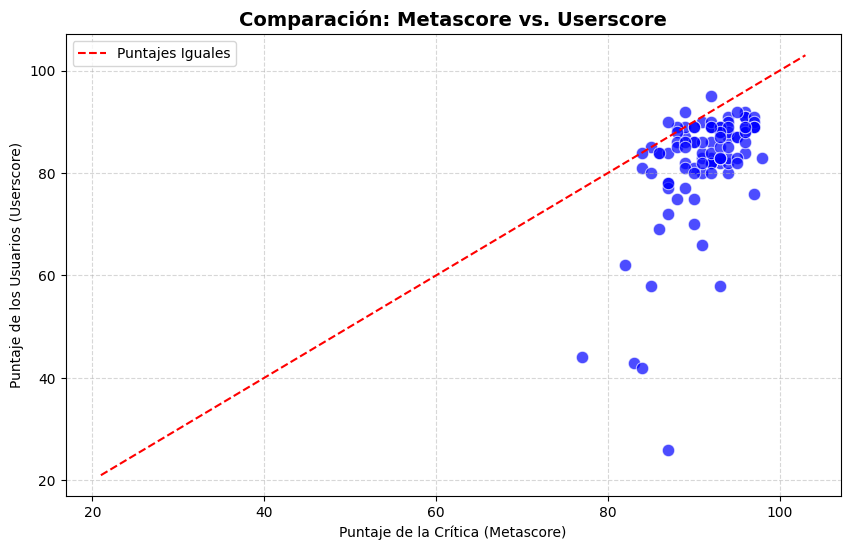

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='metascore', y='userscore', color='blue', alpha=0.7, s=80)

minimo = min(df['metascore'].min(), df['userscore'].min()) - 5
maximo = max(df['metascore'].max(), df['userscore'].max()) + 5
plt.plot([minimo, maximo], [minimo, maximo], color='red', linestyle='--', label='Puntajes Iguales')

plt.title('Comparación: Metascore vs. Userscore', fontsize=14, fontweight='bold')
plt.xlabel('Puntaje de la Crítica (Metascore)')
plt.ylabel('Puntaje de los Usuarios (Userscore)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

Casi todos los elementos están por debajo de la línea roja, lo que nos indican que los críticos casi siempre puntúan los juegos con puntajes más altos que los usuarios, hipótesis que ya veníamos planteando anteriormente. Los puntos en su gran mayoría se concentran entre [85, 95] para "metascore" y [80, 90] para "userscore". El resto de elementos están dispersos y alejados de esa especie de cluster, y en su gran mayoría, se debe a casos en los que los usuarios infrapuntúan los juegos, como exagerando lo malos que son. Estos puntajes son posibles anomalías, y provienen de los puntajes de los usuarios principalmente. Más adelante compararemos "userscore" con "userscore_count" para analizar esas anomalías, y ver si de verdad es el juego tan malo o fueron unos pocos usuarios los que jugaron y puntuaron muy mal el juego.
<br>
<br>

Respecto a la relación entre ambos atributos, podemos observar una correlación positiva entre ellos: cuando "metascore" es alto, "userscore" suele ser alto también. Lo que no coinciden es en el nivel de puntaje, los usuarios suelen infrapuntuar los juegos respecto a los críticos.

#### Instancia 2.3.2: Análisis de relación entre "genres" y "userscore"

La idea es analizar cómo influye el género de un videojuego en el puntaje del mismo de los usuarios "userscore". Utilizaremos boxplots ya que permiten resumir estadísticamente demasiado bien atributos numéricos como "userscore", y podemos hacer un boxplot por cada género y comparar los boxplots directamente.

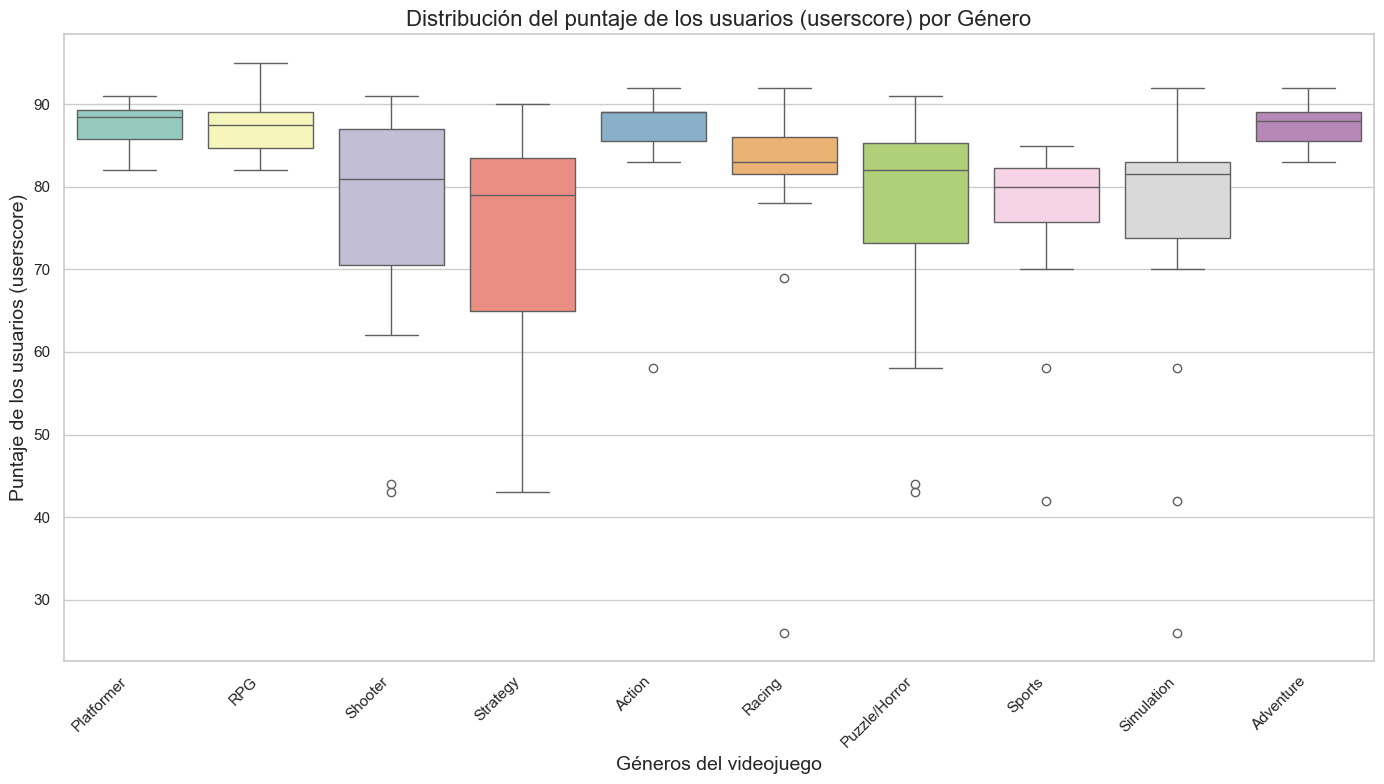

In [ ]:
df_genres = df.copy()
df_genres["genres"] = df_genres["genres"].str.split(',').apply(lambda x: [i.strip() for i in x] if isinstance(x, list) else x)
df_genres = df_genres.explode("genres")

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(data=df_genres, x="genres", y="userscore", hue="genres", palette="Set3", legend=False)

plt.title("Distribución del puntaje de los usuarios (userscore) por Género", fontsize=16)
plt.xlabel("Géneros del videojuego", fontsize=14)
plt.ylabel("Puntaje de los usuarios (userscore)", fontsize=14)

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

A partir del boxplot podemos hacer varias observaciones:
* Géneros mejores puntuados: Los juegos de los géneros Platformer, RPG, Action, Adventure y Racing presentan las puntuaciones más altas y estables. El boxplot y las astas son pequeños, los puntajes presentan baja diserpsión, por eso decimos que es estable. Además, el boxplot se encuentra en la parte superior de las puntuaciones, por eso decimos que los puntajes son altos. A pesar de esto, hay 2 juegos de género Racing y 1 juego de género Action que presentan bajo puntaje de los usuarios respecto a los demás juegos de esa clasificación. Esos 3 juegos constituirían posibles anomalías en el puntaje.
* Géneros peores puntuados: Los juegos de los géneros Shooter, Strategy y Puzzle/Horror tienen boxplots más grandes, lo que indica que las puntuaciones que los usuarios les asignan difieren más entre sí, el "userscore" es más disperso. Además, presentan puntuaciones un poco más bajas, teniendo una mediana más cercana a 80 (mientras que Platformer, RPG y ese grupo tenían una mediana más cercana a 90).
* Géneros de puntaje intermedio: Los juegos de género Simulation y Sports presentan boxplots de tamaño moderado y puntaje entre 75 y 83 aproximadamente.
* En casi todos los boxplots se cumple que la mediana está más cerca de la parte superior de la caja que de la parte inferior, lo que cumple con la distribución asimétrica negativa que detectamos en la actividad 2.2 (descripción de los datos). La excepción a esto es el género Racing.


#### Instancia 2.3.3: Análisis de relación entre "metascore" y "metascore_count"

En esta instancia queremos ver por cuántas entidades esta respaldado el voto de la crítica.
<br>

Anteriormente habíamos notado que las calificaciones de la prensa estaban mayormente concentradas en puntajes altos, pero existían algunos juegos con notas bastante bajas. Queremos ver si el peso estadístico de estas notas es el mismo en todos los casos, o si las notas bajas coinciden con juegos con pocas reseñas. Para ello, compararemos la cantidad de críticos profesionales que reseñaron el juego con el puntaje obtenido. Tomaremos los 10 juegos mejor puntuados, 10 juegos de puntaje promedio y los 10 juegos peores puntuados, para comparar el volumen de profesionales que evaluaron esos juegos y ver si existe un sesgo respecto a la cantidad de críticos que los puntuaron.

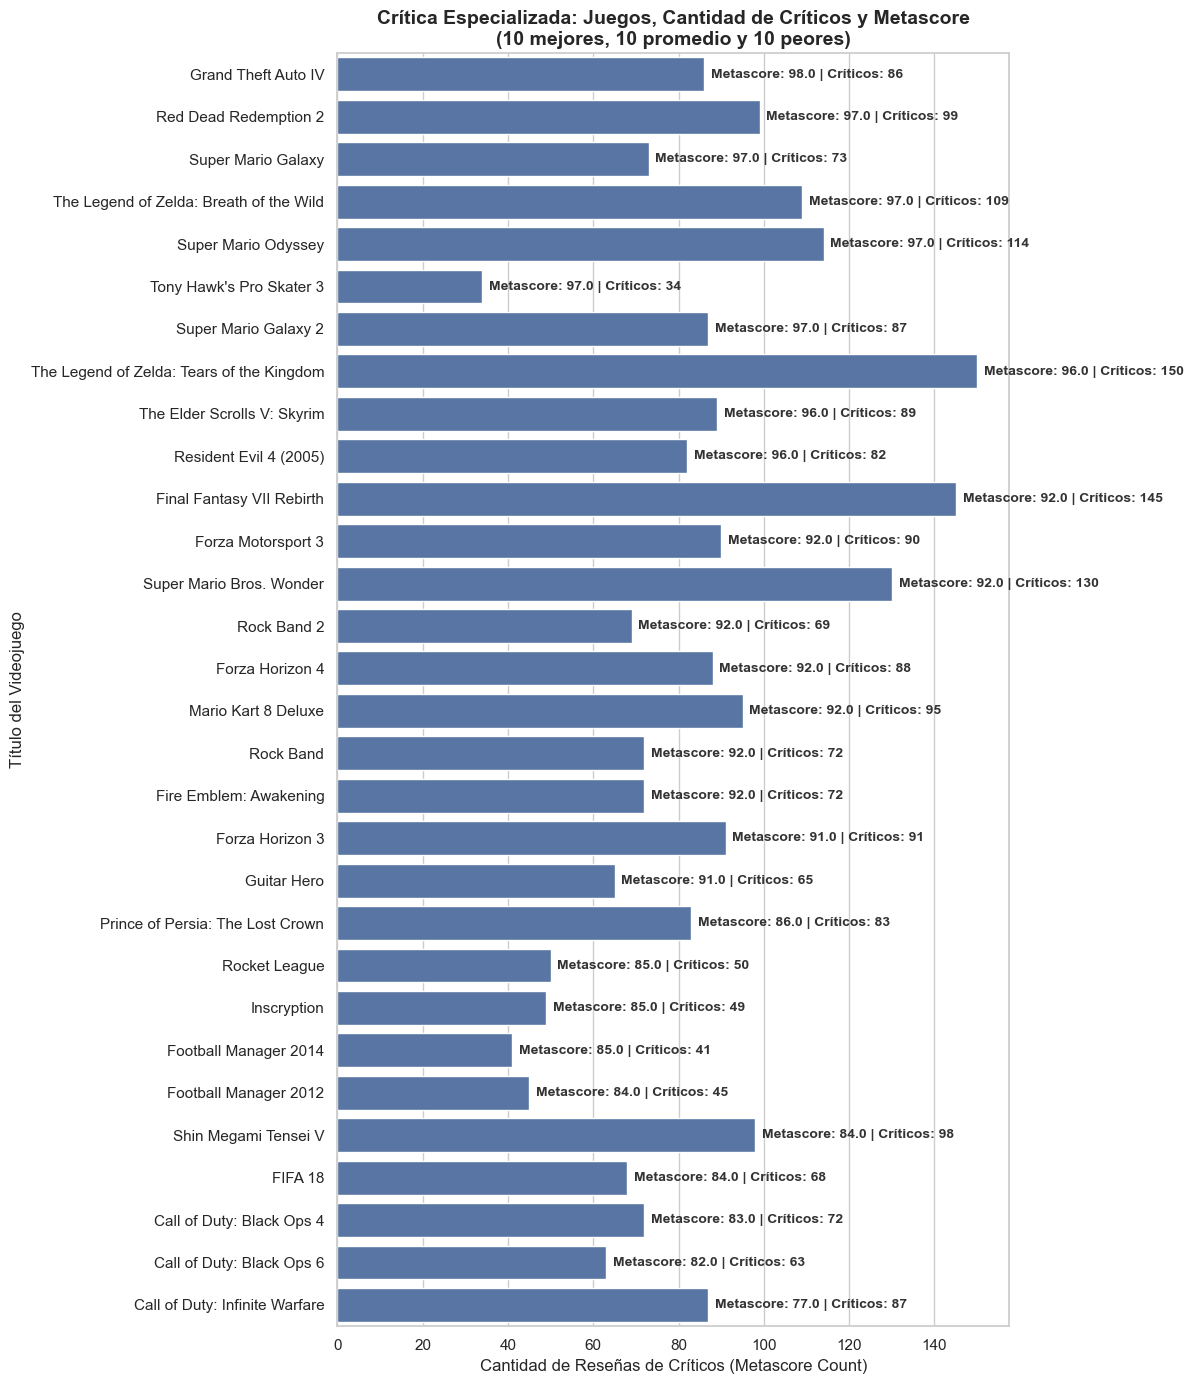

In [ ]:
# 1. Ordenar por metascore (crítica profesional)
df_ordenado = df.sort_values("metascore").reset_index(drop=True)

# 2. Seleccionar los grupos (10 de cada uno)
df_peores = df_ordenado.head(10)
df_mejores = df_ordenado.tail(10)
medio = len(df_ordenado) // 2
df_promedio = df_ordenado.iloc[medio - 5 : medio + 5]

# 3. Unir y ordenar para el gráfico (de mayor a menor puntaje)
df_muestra = pd.concat([df_mejores, df_promedio, df_peores])
df_muestra = df_muestra.sort_values("metascore", ascending=False)

# 4. Configuración visual
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 14))

# 5. Gráfico de barras usando la cantidad de reseñas de críticos
sns.barplot(
    data=df_muestra,
    x="metascore_count",  # Cambiado a la cuenta de metascore
    y="title",
    ax=ax,
    color="#4C72B0"       # Un azul profesional para diferenciarlo de los usuarios
)

# 6. Títulos y etiquetas adaptados
ax.set_title("Crítica Especializada: Juegos, Cantidad de Críticos y Metascore\n(10 mejores, 10 promedio y 10 peores)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de Reseñas de Críticos (Metascore Count)", fontsize=12)
ax.set_ylabel("Título del Videojuego", fontsize=12)

# 7. Anotaciones de texto dinámicas
for i, (count, score) in enumerate(zip(df_muestra["metascore_count"], df_muestra["metascore"])):
    # Calculamos un margen dinámico para que el texto no se pegue a la barra
    margen = ax.get_xlim()[1] * 0.01 
    ax.text(count + margen, i,
            f"Metascore: {score} | Críticos: {count}",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#333333")

plt.tight_layout()
plt.show()

Podemos observar que la cantidad de críticos no es un factor determinante que influya directamente en el puntaje final de un juego. El gráfico demuestra claramente que la excelencia (o la mediocridad) se puede alcanzar independientemente del tamaño de la cobertura mediática. Y esto lo podemos notar en los juegos mejor puntuados, un juego respaldado por 34 críticos, como es el caso de *Tony Hawk's Pro Skater 3*, logra alcanzar un "metascore" de 97. Este es exactamente el mismo puntaje alcanzado por otros juegos como *Red Dead Redemption 2*, el cual requirió el respaldo de 99 críticos, o *Super Mario Odyssey* con 113 reseñas profesionales.<br>

Esta desconexión entre el volumen de atención y la calificación obtenida también se repite en el segmento de los juegos de puntaje promedio. Por ejemplo, un título como *Mortal Kombat* consigue un "metascore" de 76 con apenas 12 críticas, mientras que *Kirby Star Allies* movilizó a 83 críticos de la prensa pero obtuvo una nota inferior de 73 puntos. <br>

Para complementar este análisis realizaremos un histograma que represente la cantidad total de criticos que puntuaron juegos en función de intervalos de "metascore". Partimos el dataset de juegos en 10 intervalos con igual cantidad de juegos según los puntajes en "metascore", con el fin de visualizar mejor si juegos con mayor/menor puntaje tienden a tener más/menos puntuaciones de criticos.

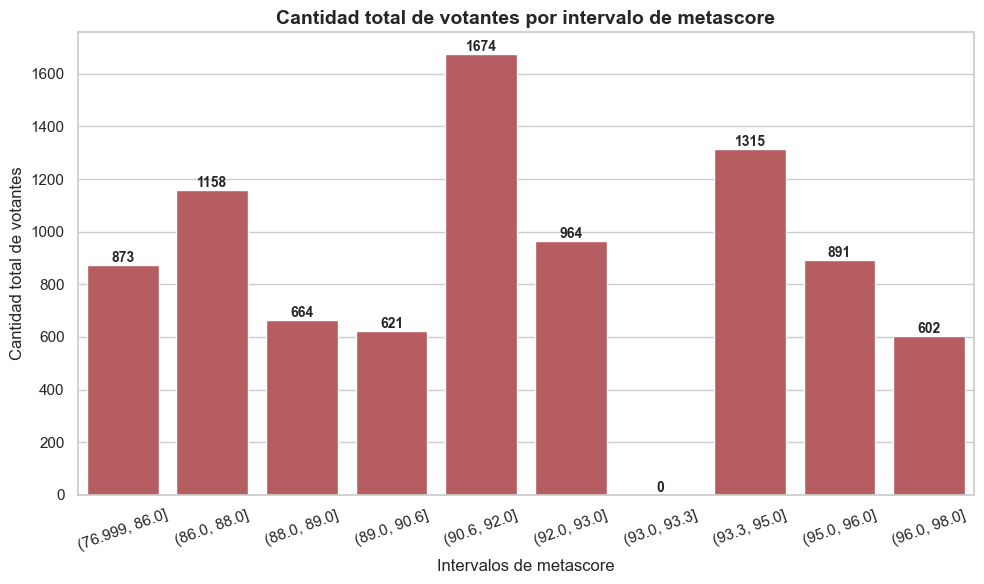

In [ ]:
# Nos quedamos solo con las columnas necesarias y quitamos nulos
df_aux = df[["metascore", "metascore_count", "title"]].dropna().copy()

# Crear 10 intervalos con igual cantidad de juegos según metascore
df_aux["intervalo_metascore"] = pd.qcut(df_aux["metascore"], q=10, duplicates='drop')

# Sumar la cantidad total de votantes por intervalo
df_intervalos = (
    df_aux
    .groupby("intervalo_metascore", observed=False)["metascore_count"]
    .sum()
    .reset_index()
)

# Pasar el intervalo a texto para que se vea bien en el gráfico
df_intervalos["intervalo_metascore"] = df_intervalos["intervalo_metascore"].astype(str)

# Gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_intervalos,
    x="intervalo_metascore",
    y="metascore_count",
    color="#C44E52"
)

plt.title("Cantidad total de votantes por intervalo de metascore", fontsize=14, fontweight="bold")
plt.xlabel("Intervalos de metascore", fontsize=12)
plt.ylabel("Cantidad total de votantes", fontsize=12)
plt.xticks(rotation=20)

# Etiquetas arriba de cada barra
for i, total in enumerate(df_intervalos["metascore_count"]):
    ax.text(i, total, f"{int(total)}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

**Conclusión**

Tras evaluar tanto los casos específicos como la distribución general por intervalos, podemos concluir que la cantidad de críticos profesionales 
funciona principalmente como un termómetro de popularidad mediática o expectativa de mercado, pero en ningún término determina la calidad de un videojuego.

Como observamos en los datos, existen títulos que logran un altísimo "metascore" con pocas reseñas de críticos, mientras que otros juegos concentran una alta cantidad de reseñas de críticos pero no logran superar el puntaje promedio. Asimismo, el gráfico de intervalos demuestra que el volumen total de reseñas fluctúa de manera irregular: la prensa no reserva sus opiniones exclusivamente para los mejores juegos, sino que hay reseñas para todos los juegos independientemente de su calidad. Los juegos de "metascore" promedio en el dataset parecen recibir un poco más de reseñas, lo que coinciden con juegos conocidos o de gran presupuesto que llaman la atención independientemente de si son buenos o malos.

#### Instancia 2.3.4: Análisis de relación entre "userscore" y "userscore_count"

Anteriormente habíamos notado que había solo unos pocos juegos que alcanzaban puntuaciones muy bajas con respecto a la mayoría de juegos. Queremos ver si se trataba de anomalías o no, y una de las causas de estas anomalías podían ser unos pocos usuarios puntuandolos muy bajo a esos juegos y sesgando la puntuación. Para ello, compararemos la cantidad de usuarios que puntuaron el juego con el puntaje obtenido. Tomaremos los 10 juegos mejor puntuados, 10 juegos de puntaje promedio y los 10 juegos peores puntuados, para comparar el volumen de usuarios que puntuaron esos juegos y ver si algo tiene que ver con estas desviaciones del comportamiento normal.
<br>
<br>

Para esta representación utilizamos un gráfico de barras horizontales. Es como un diagrama de postes horizontal, los postes horizontales o barras representan el volumen de votantes. De todas maneras, incluimos la cantidad de usuarios que puntuaron al lado del juego porque cuando la barra es muy pequeña no se alcanza a distinguir bien cuántos puntuaron. Junto a la barra incluimos también el nombre del juego y el puntaje que obtuvo.

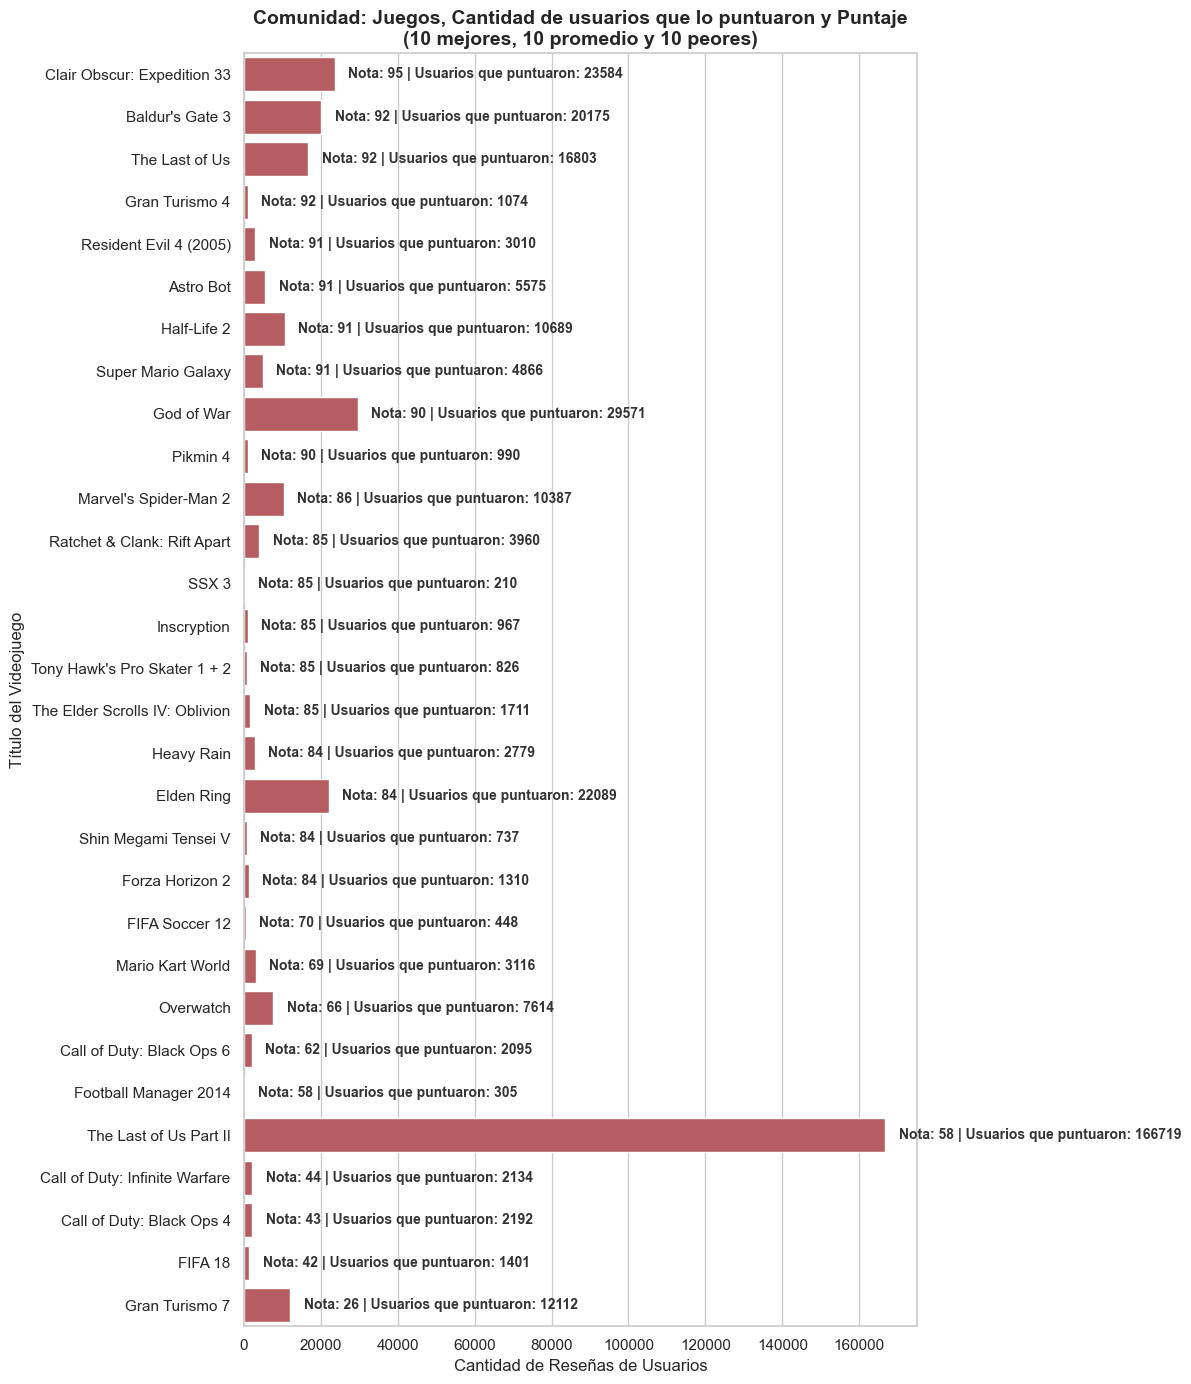

In [ ]:
# Ordenar por userscore
df_ordenado = df.sort_values("userscore").reset_index(drop=True)

# Los 10 juegos peores puntuados
df_peores = df_ordenado.head(10)

# Los 10 juegos mejor puntuados
df_mejores = df_ordenado.tail(10)

# Los 10 juegos con puntaje promedio
medio = len(df_ordenado) // 2
df_promedio = df_ordenado.iloc[medio - 5 : medio + 5]

# Unir los 3 dfs de los 10 mejores, peores y promedios
df_muestra = pd.concat([df_mejores, df_promedio, df_peores])
df_muestra = df_muestra.sort_values("userscore", ascending=False)

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 14))

sns.barplot(
    data=df_muestra,
    x="userscore_count",
    y="title",
    ax=ax,
    color="#C44E52"
)

ax.set_title("Comunidad: Juegos, Cantidad de usuarios que lo puntuaron y Puntaje\n(10 mejores, 10 promedio y 10 peores)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Cantidad de Reseñas de Usuarios", fontsize=12)
ax.set_ylabel("Título del Videojuego", fontsize=12)

# TEXTO AL LADO DE CADA BARRA
for i, (count, score) in enumerate(zip(df_muestra["userscore_count"], df_muestra["userscore"])):
    margen = ax.get_xlim()[1] * 0.02
    ax.text(count + margen, i,
            f"Nota: {score} | Usuarios que puntuaron: {count}",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#333333")

plt.tight_layout()
plt.show()

Podemos observar que los valores más bajos y altos de "userscore" encontrados en el dataset no se trata de unos pocos usuarios que los puntuaron muy mal o muy bien, sino que fueron más de 1000 usuarios los que consideraron a ese juego muy bueno o muy malo. Esto nos da cierta base sólida de que en verdad ese juego era muy malo o muy bueno para la comunidad, por lo que podemos confiar en ese "userscore". Hasta podemos afirmar que esos puntajes extremos tienen una base sólida de usuarios que los respaldan, como en el caso de Gran Turismo 7, un juego muy puntuado por los usuarios pero que registra una puntuación increíblemente baja (puntuación 26, usuarios que puntuaron: 12112). Sucede lo mismo para los 3 juegos de mayor puntuación, con puntajes promedio que alcanzan los 95 puntos realizados por más de 10000 usuarios. En cualquier caso, los puntajes extremos no son una anomalía sesgada por unos pocos usuarios, sino producto de un juego realmente aclamado/detestado por la comunidad.
<br>
<br>

Y para complementar este análisis realizaremos un histograma que represente la cantidad total de usuarios que puntuaron juegos en función de intervalos de "userscore". Partimos el dataset de juegos en 10 intervalos con igual cantidad de juegos según los puntajes en "userscore", con el fin de visualizar mejor si juegos con mayor/menor puntaje tienden a tener más/menos puntuaciones de usuarios.

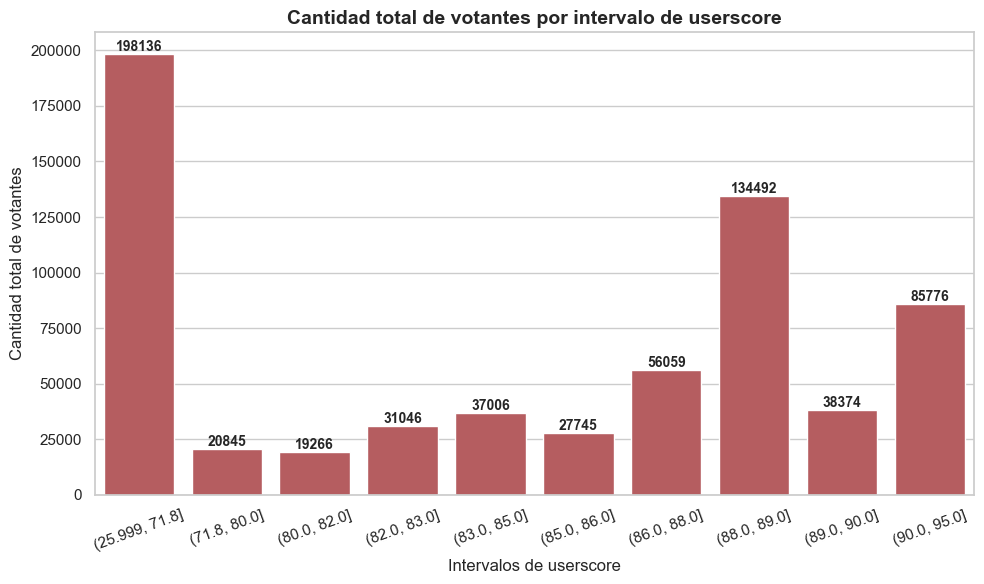

In [ ]:
# Nos quedamos solo con las columnas necesarias y quitamos nulos
df_aux = df[["userscore", "userscore_count", "title"]].dropna().copy()

# Crear 10 intervalos con igual cantidad de juegos según userscore
df_aux["intervalo_userscore"] = pd.qcut(df_aux["userscore"], q=10)

# Sumar la cantidad total de votantes por intervalo
df_intervalos = (
    df_aux
    .groupby("intervalo_userscore", observed=False)["userscore_count"]
    .sum()
    .reset_index()
)

# Pasar el intervalo a texto para que se vea bien en el gráfico
df_intervalos["intervalo_userscore"] = df_intervalos["intervalo_userscore"].astype(str)

# Gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=df_intervalos,
    x="intervalo_userscore",
    y="userscore_count",
    color="#C44E52"
)

plt.title("Cantidad total de votantes por intervalo de userscore", fontsize=14, fontweight="bold")
plt.xlabel("Intervalos de userscore", fontsize=12)
plt.ylabel("Cantidad total de votantes", fontsize=12)
plt.xticks(rotation=20)

# Etiquetas arriba de cada barra
for i, total in enumerate(df_intervalos["userscore_count"]):
    ax.text(i, total, f"{int(total)}", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

**Conclusiones:**
* Vemos que los juegos con "userscore" extremos, tanto altos como bajos, tienden a tener mayor cantidad de usuarios. Pueden ser juegos muy esperados que salieron y decepcionaron, por lo que terminan con muchos usuarios que lo puntúan bajo, o un juego popular y ampliamente aceptado por los usuarios.  
* El primer intervalo está distorsionado por el juego The Last of Us Part II, que cómo observamos anteriormente tiene aproximadamente 160000 usuarios que lo puntuaron, un valor muy superior al resto de videojuegos. Si se excluyera este juego del análisis, el intervalo sería similar a la de los intervalos intermedios.
* En el último intervalo, correspondiente a los mayores valores de "userscore", sin embargo, hay como 5 juegos que presentan una cantidad considerable de usuarios, alrededor de 20000 votantes, lo que refuerza la idea de que los juegos mejor votados concentran una gran cantidad de puntuaciones.
* En general, los intervalos intermedios presentan cantidades de usuarios relativamente similares entre sí, con aglunas variaciones puntuales como la del intervalo [88, 89], posiblemente distorsionada por la presencia de algún juego muy popular.
* En conjunto, considerando el juego "The Last of Us" un outlier, los juegos que concentran mayores cantidades de jugadores o con mayor cantidad de usuarios que los puntuaron, tienden a tener puntuaciones más altas, aunque no es un indicador super fiable de alto puntaje.

#### Instancia 2.3.5: Análisis de relación entre "genres" y "platforms"

Para realizar este análisis, vamos a enfocarnos en las principales plataformas:
* PC.
* Xbox (incluye Xbox 360, Xbox One, Xbox Series X y Xbox).
* PlayStations (incluye PlayStation 3, PlayStation 4, PlayStation 5, PlayStation 2 y PlayStation).
* Nintendo Switch (incluye Nintendo Switch y Nintendo Switch 2).
<br>
<br>

Agruparemos los juegos en estas 4 categorías y no consideraremos las otras plataformas ya que son demasiadas plataformas que contienen pocos juegos y molestan en la visualización de lo importante.
<br>
<br>

Lo que queremos visualizar es la cantidad de juegos de c/género presentes por plataforma. Y para ello utilizaremos un mapa de calor, en el que cada celda tendrá un valor y color asignado. El valor será la cantidad de juegos de ese género que hay en esa plataforma, y la intensidad del color representará qué tan grande es ese valor. Además, queremos saber cuántos juegos hay por categoría de plataforma, así que ese análisis también lo incluimos en el código.

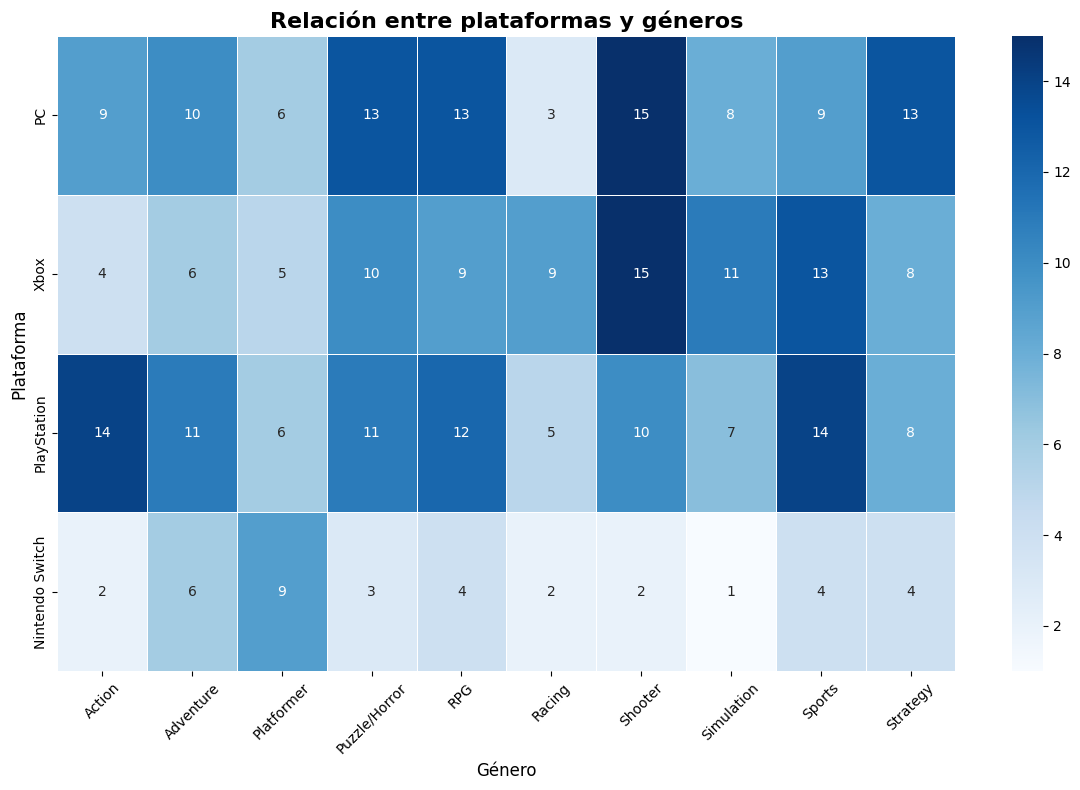

Cantidad de juegos por plataforma:
PC: 57 juegos
Xbox: 55 juegos
PlayStation: 60 juegos
Nintendo Switch: 25 juegos


In [ ]:
# Separar géneros
df_gen = df.assign(genero=df['genres'].str.split(',')).explode('genero')
df_gen['genero'] = df_gen['genero'].str.strip()

# Separar plataformas
df_plat_gen = df_gen.assign(plataforma=df_gen['platforms'].str.split(',')).explode('plataforma')
df_plat_gen['plataforma'] = df_plat_gen['plataforma'].str.strip()

# Agrupar plataformas en 4 categorías principales
mapeo_plataformas = {
    'PC': 'PC',

    'Xbox': 'Xbox',
    'Xbox 360': 'Xbox',
    'Xbox One': 'Xbox',
    'Xbox Series X': 'Xbox',

    'PlayStation': 'PlayStation',
    'PlayStation 2': 'PlayStation',
    'PlayStation 3': 'PlayStation',
    'PlayStation 4': 'PlayStation',
    'PlayStation 5': 'PlayStation',

    'Nintendo Switch': 'Nintendo Switch',
    'Nintendo Switch 2': 'Nintendo Switch'
}

# Crear columna agrupada
df_plat_gen['plataforma_grupo'] = df_plat_gen['plataforma'].map(mapeo_plataformas)

# Eliminar plataformas que no pertenecen a esas 4 categorías
df_plat_gen = df_plat_gen.dropna(subset=['plataforma_grupo'])

# Evitar doble conteo del mismo juego en la misma plataforma agrupada y género
df_plat_gen = df_plat_gen.drop_duplicates(subset=['title', 'plataforma_grupo', 'genero'])

# Resetear índice
df_plat_gen = df_plat_gen.reset_index(drop=True)

# Tabla cruzada
tabla_cruzada = pd.crosstab(df_plat_gen['plataforma_grupo'], df_plat_gen['genero'])

# Ordenar filas
orden_plataformas = ['PC', 'Xbox', 'PlayStation', 'Nintendo Switch']
tabla_cruzada = tabla_cruzada.reindex(orden_plataformas)

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tabla_cruzada, annot=True, cmap='Blues', fmt='d', linewidths=.5)

plt.title('Relación entre plataformas y géneros', fontsize=16, fontweight='bold')
plt.ylabel('Plataforma', fontsize=12)
plt.xlabel('Género', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Cantidad de juegos únicos por plataforma
juegos_por_plataforma = (
    df_plat_gen
    .groupby('plataforma_grupo')['title']
    .nunique()
    .reindex(orden_plataformas)
)

print("Cantidad de juegos por plataforma:")
for plataforma, cantidad in juegos_por_plataforma.items():
    print(f"{plataforma}: {cantidad} juegos")

**Conclusiones:**
* La primera observación es que las plataformas PC, Xbox y PlayStation están mucho más parejas de lo que pensabamos inicialmente, teniendo aproximadamente la misma cantidad de juegos (entre 55 y 60).
* Nintendo Switch domina en los juegos del género Platformer, lo cuál tiene sentido ya que Nintendo se especializa en juegos de plataforma. Lo que le da más fuerza a este valor es que Nintendo tiene pocos juegos comparados a las otras plataformas y sin embargo sigue dominando el género. En el resto de géneros, Nintendo Switch prácticamente no aparece.
* Xbox y PC dominan los juegos del género Shooter. Ambas plataformas están muy asociadas a éste género, estos valores tienen sentido.
* Más allá de estas observaciones, podemos ver más cosas, como la dominancia de PlayStation en los juegos del género Action, o la tendencia de Xbox de dominar los juegos de género Racing. Pero también tenemos que tener en cuenta que estamos hablando de cantidades bajas de juegos, y las conclusiones que realicemos pueden estar sesgadas por cuestiones probabilísticas. Si calcularamos el intervalo de confianza que obtenemos de tomar 100 juegos y asignarle géneros y plataformas a c/uno, por más que PlayStation tenga más probabilidades de tener juegos Shooter (por decir un ejemplo), hay bastantes probabilidades de que justo se seleccionen juegos Shooter de la plataforma Xbox y parezca que la tendencia es que Xbox tenga juegos de género Shooter, cuando no es así. Necesitaríamos más juegos para asegurar que estas correspondencias son reales.

#### Instancia 2.3.5: Análisis de relación entre "userscore" y "userscore_sentiment"

Analicemos también la relación entre estos dos atributos, que en sí estan hablando de una misma propiedad del juego en el dataset, pero bien podrían contradecirse constituyendo una inconsistencia. Para ello, veamos los rangos de "userscore" en los que se mueve cada "userscore_sentiment"

In [ ]:
df.groupby("userscore_sentiment")["userscore"].agg(["min", "max", "count"])

,min,max,count
userscore_sentiment,,,
Generally favorable,75,89,76
Generally unfavorable,26,44,4
Mixed or average,58,72,7
Universal acclaim,90,95,13


Rangos ordenados de "userscore" para cada "userscore_sentiment":
* Generally unfavorable: [26, 44]
* Mixed or average: [58, 72]
* Generally favorable: [75, 89]
* Universal acclaim: [90, 95]
<br>
<br>

Cada "userscore_sentiment" tiene su propio rango que no se interseca en ningun valor con los rangos de los otros "userscore_sentiment". No hay inconsistencias entre estos dos valores, "userscore_sentiment" solo pone en palabras lo que el valor de "userscore" nos dice. Dado que no hay juegos en algunos intervalos de valores de userscore, no tenemos delimitados exactamente donde termina y donde empieza cada "userscore_sentiment", pero consultando en la web, los rangos reales de puntaje para videojuegos son:
* Overwhelming dislike: [0, 19]
* Generally unfavorable: [20, 49]
* Mixed or average: [50, 74]
* Generally favorable: [75, 89]
* Universal acclaim: [90, 100]
<br>
<br>

Estos rangos reales se acoplan perfectamente a lo observado en el dataset. Los rangos están sacados de [Wikipedia](https://en.wikipedia.org/wiki/Metacritic)

### Actividad 2.4: Verificación de la calidad de los datos

#### Instancia 2.4.1: Análisis de valores nulos

Recapitulando, teníamos 5 valores nulos en el atributo "rating". Los nulos pueden tener varias explicaciones lógicas. Pueden ser porque:
* El juego es apto para todo público y no se especificó porque no tiene restricciones.
* El juego no fue clasificado por ESRB.
* El juego si tiene clasificación pero el dataset no la registró porque la clasificación se realizó hace poco y el juego se cargó hace mucho en el dataset.
* El juego es poco conocido y por ende ESRB no se preocupó en clasificarlo.
<br>
<br>

Esta última posibilidad hace bastante sentido, así que podemos corroborarla observando las fechas de lanzamiento de los 5 juegos con nulo en "rating" y compararlas con el análisis de la distribución estadística de "releaseDate", verificando si estos datos siguen o no esa distribución.
<br>
<br>

Incluiremos además el userscore_count, para ver cuántos usuarios los calificaron, lo que nos dará una pista de cuan popular es y quizás podamos descubrir que ESRB no lo clasificó al ser un juego medio desconocido.

In [ ]:
df[df["rating"].isna()][["title", "rating", "releaseDate", "userscore_count"]]

,title,rating,releaseDate,userscore_count
12,Crypt of the NecroDancer,NaN,2015-04-23,300
16,Divinity: Original Sin II,NaN,2017-09-14,3152
28,Forza Horizon 2,NaN,2014-09-30,1310
47,Hollow Knight: Silksong,NaN,2025-09-04,6439
49,Inscryption,NaN,2021-10-19,967


En esta tabla, podemos ver que releaseDate y userscore_count no contribuyen de ninguna manera a que el rating sea nulo.
<br>
<br>

Ya que son 5 juegos, lo mejor es buscar uno por uno a ver si en realidad están clasificados por ESRB o no lo están. Buscamos esa información y encontramos que los 5 han sido clasificados por ESRB:
| Título del juego | Clasificación ESRB |
|------------------|--------------------|
| Crypt of the NecroDancer | T |
| Divinity: Original Sin II | M |
| Forza Horizon 2 | E10+ |
| Hollow Knight: Silksong | E10+ |
| Inscryption | M |

<br>

Para mayor veracidad, incluimos los links de donde extraímos el ESRB:
* [Clasificación ESRB "Crypt of the NecroDancer"](https://www.esrb.org/ratings/10024302/crypt-of-the-necrodancer/)
* [Clasificación ESRB "Divinity: Original Sin II"](https://www.esrb.org/ratings/35672/divinity-original-sin-2-definitive-edition/)
* [Clasificación ESRB "Forza Horizon 2"](https://www.esrb.org/ratings/33504/forza-horizon-2/)
* [Clasificación ESRB "Hollow Knight: Silksong"](https://www.xbox.com/en-US/games/store/hollow-knight-silksong/9N116V0599HB)
* [Clasificación ESRB "Inscryption"](https://www.esrb.org/ratings/38728/inscryption/)
<br>
<br>

En caso de que decidamos utilizar este atributo para el sistema recomendador, en la fase 3 (preparación de los datos) completaremos la clasificación ESRB de estos juegos.

#### Instancia 2.4.2: Detección de valores no creíbles

En las actividades anteriores estuvimos analizando los rangos y distribuciones estadísticas de los elementos, y si bien se puede discutar la presencia de alguna anomalía, lo que no se puede discutir es que todos esos valores son creíbles y provienen de juegos reales. Algunos juegos aún pueden ser anomalías (como el userscore bajo de Gran Turismo 7), pero son creíbles.

#### Instancia 2.4.3: Detección de valores duplicados

Para la detección de duplicados, utilizaremos el título del juego "title". Más allá que en los datasets se utilice el "id" como identificador único de c/elemento, el elemento distintivo de un juego es el nombre, asíque verificaremos que no se repita ningún juego. 
<br>
<br>

Para ello, utilizaremos una función de distancia entre elementos (en este caso la de Levenshtein ya que estamos comparando textos), con una tolerancia de 5 de distancia. Pasaremos los títulos a minúsculas, eliminaremos signos de puntuación, eliminaremos espacios, y aquellos títulos que estén a 5 de distancia o menos de uno de los títulos del grupo, entrarán al grupo. Los títulos que no entran en ningún grupo, son juegos no repetidos y no apareceran en la tabla. Decidimos utilizar una tolerancia tan alta ya que observamos que no se formaban tantos grupos para analizar, y mejor falsos positivos que falsos negativos (es mejor detectar muchos duplicados que no lo son antes que no detectar un duplicado real).
<br>
<br>

La idea es que no solo se detecten dos juegos exactamente con el mismo título, sino el mismo juego escrito distinto. Por ejemplo, mientras realizabamos el trabajo vimos que algunos juegos en su segundo lanzamiento lo titulaban "Forza Horizon 2", y otros juegos lo titulaban "Divinity: Original Sin II". En este caso son dos juegos distintos, pero bien podría estar en el dataset "Forza Horizon II", que a priori es otro título pero es el mismo juego. Si se tratase del mismo juego pero escrito distinto, esa mínima diferencia nuestro código la detectará.

In [ ]:
def limpiar_titulo(titulo):
    """
    Pasa el texto a minúsculas y elimina cualquier espacio o signo de puntuación,
    dejando solo letras y números.
    """
    t = str(titulo).lower()
    t = re.sub(r'[^a-z0-9]', '', t)
    return t

def agrupar_duplicados(dataframe, columna_titulo='title', tolerancia=5):
    """
    Busca títulos similares en un DataFrame y devuelve otro DataFrame 
    solo con los grupos de posibles duplicados.
    """
    # 1. Extraemos los títulos únicos para no hacer trabajo doble
    titulos = dataframe[columna_titulo].dropna().unique()
    
    # 2. Pre-calculamos la versión "limpia" de cada título
    titulos_limpios = {t: limpiar_titulo(t) for t in titulos}
    
    # 3. Inicializamos el grafo
    G = nx.Graph()
    G.add_nodes_from(titulos)
    
    # 4. Comparamos todos contra todos (pares únicos)
    for t1, t2 in combinations(titulos, 2):
        # Usamos las versiones sin espacios ni puntuación
        limpio1 = titulos_limpios[t1]
        limpio2 = titulos_limpios[t2]
        
        # Si la distancia es menor o igual a 4, creamos una conexión
        if Levenshtein.distance(limpio1, limpio2) <= tolerancia:
            G.add_edge(t1, t2)
            
    # 5. Extraemos solo los grupos que tengan más de 1 título conectado
    grupos_duplicados = [list(comp) for comp in nx.connected_components(G) if len(comp) > 1]
    
    # 6. Armamos el DataFrame de salida para que lo revises "a manopla"
    datos_salida = []
    for i, grupo in enumerate(grupos_duplicados, start=1):
        datos_salida.append({
            'Titulos sospechosos': "  |  ".join(grupo) # Un separador claro a la vista
        })
        
    df_resultados = pd.DataFrame(datos_salida)
    
    return df_resultados


df_revision = agrupar_duplicados(df, columna_titulo='title', tolerancia=5)
df_revision

,Titulos sospechosos
0,Call of Duty: Black Ops 6 | Call of Duty: Black Ops 4 | Call of Duty: Black Ops
1,Half-Life 2 | INSIDE | Pikmin 4 | DOOM 3 | Fallout 3 | XCOM 2 | Halo 2 | SSX 3
2,Dead Space (2008) | Dead Space 2
3,FIFA Soccer 10 | FIFA Soccer 12
4,Football Manager 2014 | Football Manager 2012
5,Forza Horizon 3 | Forza Horizon 5 | Forza Horizon 2 | Forza Horizon 4
6,Forza Motorsport 6 | Forza Motorsport 3 | Forza Motorsport 4
7,God of War | Persona 5 Royal | Gears of War | Persona 5
8,Gran Turismo 7 | Gran Turismo 4
9,Guitar Hero | Guitar Hero II


En su mayoría, vemos juegos que son de la misma saga pero diferentes versiones. Los únicos casos que son posibles duplicados reales son:
* Dead Space (2008) | Dead Space 2: No son duplicados ya que el primero es la entrega original y el segundo es su secuela directa con una historia y mecánicas completamente distintas.
* Persona 5 | Persona 5 Royal: No son duplicados porque aunque comparten la misma base narrativa la versión Royal es una expansión masiva que añade personajes y decenas de horas de contenido nuevo, son juegos diferentes.
* Resident Evil 4 | Resident Evil 4 (2005): No son duplicados debido a que el primero hace referencia al remake hecho desde cero con tecnología moderna mientras que el segundo es el juego original.
* Tony Hawk's Pro Skater 3 | Tony Hawk's Pro Skater 1 + 2: No son duplicados puesto que el primero es la tercera entrega original de la saga y el segundo es un remake moderno de los dos primeros juegos (no incluye contenido de la tercera entrega).

#### Instancia 2.4.4: Análisis de anomalías en "userscore"

Anteriormente, veíamos juegos que registraban puntuaciones de usuarios increíblemente bajas, y que las puntuaciones de usuarios a menudo eran mucho más bajas que las realizadas por los críticos. Acá vamos a analizar si esas puntuaciones tan bajas son anomalías por algún fenómeno en específico o si el juego es realmente malo y odiado en consenso por la comunidad.
<br>
<br>

Vamos a analizar los 5 juegos peores puntuados por los usuarios:
* Gran Turismo 7
* FIFA 18
* Call of Duty: Black Ops 4.¿
* Call of Duty: Infinite Warfare
* The Last of Us Part II
<br>
<br>

Primero comparemos el "userscore" de estos juegos con su "metascore":

In [ ]:
juegos_a_filtrar = [
    "Gran Turismo 7", 
    "FIFA 18", 
    "Call of Duty: Black Ops 4", 
    "Call of Duty: Infinite Warfare", 
    "The Last of Us Part II"
]
df[df['title'].isin(juegos_a_filtrar)][['title', 'userscore', 'metascore']]


,title,userscore,metascore
7,Call of Duty: Black Ops 4,43,83.0
9,Call of Duty: Infinite Warfare,44,77.0
19,FIFA 18,42,84.0
40,Gran Turismo 7,26,87.0
90,The Last of Us Part II,58,93.0


El rango de "metascore" es [77, 98], con una media y una mediana de 92 aproximadamente. Teniendo esto en cuenta:
* Call of Duty: Black Ops 4, Call of Duty: Infinite Warfare y FIFA 18 presentan "metascore" bajos en comparación con otros juegos, lo que se condice con "userscore"
* Gran Turismo 7 presenta un "metascore" bajo pero más cercano al promedio, el puntaje de los usuarios parece un poco exagerado comparado al puntaje de los críticos.
* The Last of Us Part II presenta un "metascore" que supera el promedio, algo inusual para un juego mal puntuado por los usuarios.
<br>
<br>

Investigando un poco estos juegos y viendo qué opina la comunidad de jugadores sobre los mismos, descubrimos cosas importantes:
* Gran Turismo 7 (26) - Mecánicamente y gráficamente es un juego apreciado por la comunidad. Lo que sucede es que el sistema de recompensas del juego es muy lento, los jugadores tienen que repetir la misma carrera muchísimas veces para obtener ganancias reales, y con plata en la vida real es imposible comprar algo, los precios están super inflados, cualquier mini-compra sale carísima. Los usuarios han canalizado en las votaciones de Metacritic este enojo por las recompensas ridículamente bajas. No es el mejor juego de los Gran Turismo, pero no es tan malo como lo pintan el "userscore", la puntuación está sesgada.
* FIFA 18 (42) - El juego no es tan malo como lo plasma su "userscore", pero tampoco es bueno. Los usuarios se quejan de las mecánicas recicladas de FIFA 17, el motor de colisiones genera rebotes absurdos, y la IA de los defensores es errática. Esto sumado a la manipulación de partidos (si ganas muchos seguidos, el juego te va a hacer perder para mantenerte "enganchado", errarás los pases, remates, y el rival le saldrá todo), lo hace un juego de promedio para abajo.
* Call of Duty: Black Ops 4 (43) - El juego no incluyó un modo campaña para un jugador, querían enfocarse 100% en el multijugador. Esto no le gusto para nada a los usuarios que canalizaron esa frustración en oleadas de votos negativos al juego, sentían que les vendieron un juego incompleto. Pero hoy en día es considerado un buen juego, "userscore" no refleja la calidad del juego.
* Call of Duty: Infinite Warfare (44) - La comunidad venía harta de años con shooters futuristas con jetpacks y exageraciones poco realistas. Querían algo clásico. Cuando salió el trailer, que estaba ambientado en el espacio exterior (algo super futurista), la comunidad se enojó y antes de probarlo lo condenaron y le bajaron la nota. Además, justo salió Battlefield, otro juego mucho más realista que era lo que los usuarios querían, y lo contrastaron con ese juego. No es un juego malo, solo es una votación sesgada por una situación particular.
* The Last of Us Part II (58): Este juego es muy polarizante, hay gente que lo odia y gente que lo ama. Hubo muchas filtraciones antes de que salga, situaciones como la muerte de personajes muy queridos y obligarte a jugar con el personaje antagonista. Esto se sabía antes de que salga, y ya por la narrativa los usuarios lo detestaron y lo puntuaron 0 el mismo día que salió. Creemos que es un juego sobrepenalizado por los usuarios que no les gustó, pero que en realidad no es mal juego.
<br>
<br>

Esta información fue extraída principalmente a partir de opiniones de Reddit y otros sitios.
<br>
<br>

**En resumen:**
* Gran Turismo - Votación sesgada, buen juego.
* FIFA 18 - Votación un poquito sesgada, aún así no es buen juego.
* Call of Duty: Black Ops 4 - Votación sesgada, buen juego.
* Call of Duty: Infinite Warfare - Votación sesgada, buen juego.
* The Last of Us Part II - Votación sesgada, buen juego.
<br>
<br>

Al principio, pensábamos que el "userscore" era un medidor sólido de qué tan bueno es un juego. Pero ahora vemos que esa variabilidad es más debido a opiniones sesgadas que a la calidad del juego, y que los "userscore" más bajos están sesgados. Esto tendremos que tenerlo presente a la hora de preparar los datos. Si es que realmente consideramos este campo para el sistema recomendador, juegos como Gran Turismo 7 deberían ser presentados a usuarios que les guste el género "Racing", y no deberían ser ocultados solo por su bajo "userscore". "userscore" puede ser un factor influyente pero no determinante. Estos "userscore" son anomalías generadas por un comportamiento: el enojo de los usuarios y la creación masiva de cuentas para manifestar su odio por una situación particular en el juego.

#### Instancia 2.4.5: Confirmar validez de tipos y dominios definidos

Hagamos una revisión sobre los tipos de datos y conociendo su semántica asociada, veamos si están bien codificados

In [ ]:
df.dtypes

id                       int64
title                      str
releaseDate                str
rating                     str
genres                     str
description                str
platforms                  str
metascore              float64
metascore_count          int64
metascore_sentiment        str
userscore                int64
userscore_count          int64
userscore_sentiment        str
platform_metascores        str
developer                  str
publisher                  str
dtype: object

A continuación evaluamos cada atributo en base a su codificación y si es la adecuada para la semántica propia de ese campo.
| Variable | Tipo de dato | Evaluación |
|----------|--------------|------------|
| id | int64 | Bien codificado ✅ |
| title | str | Bien codificado ✅ |
| releaseDate | str | Mal codificado ❌, las fechas tienen su propio tipo date |
| rating | str | Bien codificado ✅ |
| genres | str | Mal codificado ❌, los géneros deberían estar en una lista y no separados por comas en un solo string |
| description | str | Bien codificado ✅ |
| platforms | str | Mal codificado ❌, deberían estar en una lista y no en un solo string separado por comas |
| metascore | float64 | Parcialmente bien codificado ⚠️, metascore es un número entero |
| metascore_count | int64 | Bien codificado ✅ |
| metascore_sentiment | str | Bien codificado ✅ |
| userscore | int64 | Bien codificado ✅ |
| userscore_count | int64 | Bien codificado ✅ |
| userscore_sentiment | str | Bien codificado ✅ |
| platform_metascores | str | Mal codificado ❌, deberían estar en una lista y no en un solo string separado por comas |
| developer | str | Bien codificado ✅ |
| publisher | str | Bien codificado ✅ |

<br>
<br>
Esto nos sirve para tener una idea de algunos ajustes que tendremos que realizar en la fase 3 (preparación de datos), pero aunque el atributo esté bien codificado, posiblemente necesite cambios en su codificación, dependiendo de la técnica de modelado que utilicemos y lo que necesitemos.

#### Instancia 2.4.6: Evaluar la calidad global de los datos

Este dataset es suficiente para poder armar un sistema recomendador de juegos para el negocio. Los datos cumplen perfectamente con 4 de los aspectos de la calidad de los datos:
* Completitud: Solo tenemos 5 valores nulos en el campo "rating", que de necesitar utilizarlo ya tenemos disponibles los 5 valores faltantes.
* Consistencia: Buscamos títulos repetidos, buscamos inconsistencias entre el score y el sentimiento de los usuarios respecto del juego. No se ha identificado ninguna inconsistencia en toda la exploración de datos.
* Credibilidad: Los datos son creíbles, los dominios de cada atributo tienen sentido y se pueden explicar, y si se detectaron anomalías, se identificó el comportamiento que las generaba. 
* Interpretabilidad: Se comprendió perfectamente la semántica de c/atributo.
<br>
<br>

El único punto discutible es la precisión, pero únicamente por el análisis de userscore y la detección del comportamiento sesgado de los usuarios que por un asunto en particular infrapuntuaban un juego. Pero el resto de atributos ha mostrado un comportamiento sólido y no hay razones para dudar de su precisión.
<br>
<br>

Creemos que el dataset es suficiente porque el atributo de géneros del juego está completo y posee una distribución uniforme, haciendolo perfecto para basar nuestro sistema recomendador en este atributo. Luego, evaluaremos complejizar un poco el sistema incorporando otros campos.

## Fase 3 - Preparación de los datos

### Actividad 3.1: Selección de datos

Conociendo en detalle los atributos del dataset, realizamos un análisis uno por uno decidiendo si lo incluiremos o no cómo entrada para el sistema recomendador y porqué tomamos esa decisión:
* id: No incluido ❌: No aporta.
* title: No incluído ❌: Puede influir en el sentido de que si a un jugador le gusta un juego de una saga, le puede gustar otro de la misma saga. Aún así, con el objetivo de mantener el sistema lo más simple posible, queda excluído.
* releaseDate: No incluído ❌: La fecha de lanzamiento puede influir un poco en el usuario, pero aporta más complejidad que utilidad.
* rating: No incluído ❌: En cierto el grado de violencia de un juego puede influir en el gusto de los usuarios, pero creemos que incluirlo aporta más complejidad que utilidad al sistema y por eso lo excluímos.
* genres: Incluído ✅: Atributo fundamental para determinar si al usuario le gustará o no le gustará un juego.
* description: No incluído ❌: Puede funcionar como medidor de similitud entre dos juegos, aún así aporta más complejidad que utilidad.
* platforms: No incluído ❌: Solo funciona como restricción, ya que el usuario solo podrá jugar en plataformas que posee, pero no indica si le gustará o no el juego.
* metascore: No incluído ❌: Buscamos recomendaciones para usuarios, no para críticos.
* metascore_count: No incluído ❌: No aporta.
* metascore_sentiment: No incluído ❌: Es el "metascore" traducido a palabras, no aporta más información que eso.
* userscore: Incluído ✅: A pesar del sesgo que presentan algunos juegos, no podemos ignorar la opinión de los usuarios ya que algo nos están tratando de decir.
* userscore_count: No incluído ❌: No es un indicador fiable de popularidad, es más bien un indicador de que el juego le generó una emoción (positiva o negativa) al usuario.
* userscore_sentiment: No incluído ❌: Es el "userscore" traducido a palabras, no aporta más información que eso.
* platform_metascores: No incluído ❌: Es información redundante con "metascore" y "platforms"
* developer: No incluído ❌: Demasiada cardinalidad y puede influir muy poco en el gusto del usuario.
* publisher: No incluído ❌: Demasiada cardinalidad y puede influir muy poco en el gusto del usuario.

<br>
Con esto en mente, aplicamos el cambio correspondiente en el dataframe:

In [ ]:
df_preparado = df[["id", "title", "description", "platforms", "userscore", "genres"]]
df_preparado.head()

,id,title,description,platforms,userscore,genres
0,1300638463,Astro Bot,When the PS5 mothership is attacked by ASTRO’s...,PlayStation 5,91,Platformer
1,1300501848,Baldur's Gate 3,"An ancient evil has returned to Baldur's Gate,...","PC,PlayStation 5,Xbox Series X",92,RPG
2,1300044321,Battlefield 3,"As bullets whiz by, walls crumble, and explosi...","PC,Xbox 360,PlayStation 3",77,"Shooter, Strategy"
3,1300022724,BioShock,"Going beyond ""run and gun corridors,"" ""monster...","PC,Xbox 360,PlayStation 3,iOS (iPhone/iPad)",88,Shooter
4,1300287014,Bloodborne,Bloodborne is an action RPG in which you hunt ...,PlayStation 4,89,"Action, RPG"


Mantendremos las columnas "id", "title", "description" y "platforms", ya que a pesar de que el sistema recomendador no las utiliza para realizar las recomendaciones, necesitamos mostrarselas al usuario en la página.

### Actividad 3.2: Limpieza de datos

La actividad de limpieza de datos consiste en limpiar la suciedad de los datos proveniente de:
* Valores perdidos
* Inconsistencias
* Anomalías
* Ruido

<br>
Respecto a los dos atributos que utilizaremos en el sistema recoemndador, tanto "genres" como "userscore" no presentan valores perdidos ni inconsistencias. Esto lo sabemos por la exploración de datos realizada.
<br>

En lo que respecta a las anomalías, el atributo "userscore" a presentado comportamientos ciertamente anómalos en algunos juegos con puntuación baja. Analizando si tratar o no estás anomalías, decidimos no alterarlas, ya que en cierto modo reflejan la queja de los usuarios sobre algún aspecto del videojuego. Aunque ese valor de "userscore" pueda ser exagerado en algún casos, si el videojuego tiene algun aspecto despierta una emoción negativa en los usuarios que hace que vayan a puntuarlo mal a Metacritic, algo mal tiene que haber hecho el videojuego, y no podemos ignorar eso. Merece ser penalizado por el sistema recomendador.

### Actividad 3.3: Integración de datos

Esta actividad no es necesaria. Tenemos un solo dataset, no hay que integrarlo con otro, y los dos atributos que tenemos no son redudantes ni tienen correlación entre sí suficiente como para integrarlos.

### Actividad 3.4: Reducción de datos

La reducción de datos carece completamente de sentido en este proceso de minería. Tenemos solo 100 datos y 2 atributos. No tiene ningún sentido reducir la numerosidad de datos con las pocas filas que tenemos, ni reducir la dimensionalidad con las pocas columnas que utilizaremos.

### Actividad 3.5: Transformación de datos

#### Instancia 3.5.1: Transformación del atributo "genres"

El atributo "genres", tal y como analizamos en la fase 2, es un atributo multivaluado y nominal, cada juego puede pertenecer a múltiples géneros al mismo tiempo. Para nuestro modelo, necesitamos una variable numérica.
<br>

Para resolver este problema, se aplicó la técnica de codificación **One-Hot Encoding**, la cual transforma cada categoría posible en una variable binaria independiente. Entonces, se genera una nueva columna por cada género, donde el valor es 1 si el juego pertenece a dicho género y 0 en caso contrario. Posteriormente, la columna vieja de "genres" es eliminada.

In [ ]:
if 'genres' in df_preparado.columns:
	df_preparado.columns = df_preparado.columns.str.strip()
	df_generos = df_preparado['genres'].str.get_dummies(sep=', ')
	df_preparado = pd.concat([df_preparado, df_generos], axis=1)
	df_preparado.drop(columns=['genres'], inplace=True)
else:
	print("La columna 'genres' ya fue preparada")

La columna 'genres' ya fue preparada


#### Instancia 3.5.2: Transformación del atributo "userscore"

El otro atributo que utilizaremos para el sistema recomendador es "userscore". Ahora, nos quedó en una escala distinta a "genres", su dominio es [25, 95] (analizado en la fase 2). Entonces, vamos a normalizarlo en una escala [0, 1], para que no tenga más peso en el modelo solo por tener valores más grandes. La técnica de normalización que utilizaremos es la normalización **Min-Max**. Coloquialmente, lo que hace es agarrar todos los valores y apretarlos para que queden entre 0 y 1, manteniendo las proporciones. Matemáticamente, se basa en la siguiente fórmula:
<br>

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$
<br>

Aplicando esto en código:

In [ ]:
min_v, max_v = df_preparado['userscore'].min(), df_preparado['userscore'].max()
df_preparado['userscore'] = (df_preparado['userscore'] - min_v) / (max_v - min_v)

Completada la preparación del dataframe, ya no lo volveremos a modificar. Así nos quedaría el dataframe

In [ ]:
display(df_preparado.head())

,id,title,description,platforms,userscore,Action,Adventure,Platformer,Puzzle/Horror,RPG,Racing,Shooter,Simulation,Sports,Strategy
0,1300638463,Astro Bot,When the PS5 mothership is attacked by ASTRO’s...,PlayStation 5,0.942029,0,0,1,0,0,0,0,0,0,0
1,1300501848,Baldur's Gate 3,"An ancient evil has returned to Baldur's Gate,...","PC,PlayStation 5,Xbox Series X",0.956522,0,0,0,0,1,0,0,0,0,0
2,1300044321,Battlefield 3,"As bullets whiz by, walls crumble, and explosi...","PC,Xbox 360,PlayStation 3",0.739130,0,0,0,0,0,0,1,0,0,1
3,1300022724,BioShock,"Going beyond ""run and gun corridors,"" ""monster...","PC,Xbox 360,PlayStation 3,iOS (iPhone/iPad)",0.898551,0,0,0,0,0,0,1,0,0,0
4,1300287014,Bloodborne,Bloodborne is an action RPG in which you hunt ...,PlayStation 4,0.913043,1,0,0,0,1,0,0,0,0,0


Este dataframe será utilizado para modelar el sistema recomendador y para mostrar los juegos en el sistema original. Por ende, lo guardamos como .csv en la carpeta del proyecto

In [ ]:
df_preparado.to_csv("../database/games_preparado.csv", index=False)

## Fase 4 - Modelado

### Actividad 4.1: Selección de técnicas de modelado

En esta actividad no seleccionaremos una técnica de modelado estándar única, ya que los sistemas recomendadores no se basan en un único modelo predictivo tradicional. Lo que haremos es elaborar nuestra propia técnica, nuestro propio sistema recomendador con su funcionamiento. Entonces, esta actividad se basa en explicar cómo funcionará nuestro sistema recomendador.

#### Instancia 4.1.1: Enfoque general del sistema recomendador

Nuestro sistema recomendador tendrá un **enfoque híbrido** que combinará dos estrategias:
- **Filtrado colaborativo**: Recomienda ítems a partir de similitudes entre usuarios o entre ítems según interacciones históricas. 
- **Filtrado basado en contenido**: Recomienda ítems en función de la similitud entre las características del ítem y el perfil de preferencias del usuario.

La elección de este enfoque se fundamenta en que el sistema puede obtener información de dos fuentes complementarias.

Adicionalmente, el sistema incorpora un **componente de serendipia**, cuyo objetivo es favorecer la aparición de recomendaciones inesperadas pero potencialmente valiosas para el usuario. Este componente resulta importante para evitar que el recomendador se limite a sugerir únicamente ítems muy similares a los ya consumidos, ampliando así la exploración del catálogo.

Finalmente, se incorpora una señal global de calidad del videojuego a partir de su **userscore**, utilizada como un pequeño ajuste adicional para algunos cálculos.

De esta manera, el sistema se concibe desde su diseño como un recomendador híbrido, donde la recomendación de un grupo de juegos a un usuario específico resulta de evaluar:
* Componente basado en contenido (similitud entre ítem y preferencias del usuario)
* Componente colaborativo del sistema (similitud entre usuarios e ítems según interacciones históricas)
* Componente serendípico

Incluimos en la evaluación de las recomendaciones leves aportes de "userscore", para darle un poco de prioridad a juegos de mejor calidad.

Más adelante explicaremos cómo funciona cada uno de estos componentes.

#### Instancia 4.1.2: Representación de usuarios e ítems en el sistema

Para el sistema recomendador, tanto los usuarios como los ítems son representados en un mismo espacio de características. 

En nuestro caso, el espacio de características está compuesto por los siguientes géneros:
- Action
- Adventure
- Platformer
- Puzzle/Horror
- RPG
- Racing
- Shooter
- Simulation
- Sports
- Strategy

Siendo $k$ el número de géneros considerados en el sistema, cada ítem $x$ se representa mediante un vector binario $\vec{x}$:

$$
\vec{x} = (x_1, x_2, ..., x_k)
$$

donde:

- $x_i = 1$ si el ítem pertenece al género $i$
- $x_i = 0$ en caso contrario

Y cada usuario $u$ se representa mediante un vector de preferencias $\vec{u}$:

$$
\vec{u} = (u_1, u_2, ..., u_k)
$$

donde cada componente $u_i$ toma valores en el rango $[0,10]$ y representa el grado de preferencia del usuario por el género $i$.


La información de las características de los ítems se obtuvo a partir del dataset de videojuegos procesado durante la fase 3 (preparación de los datos). Están almacenadas en el archivo `games_preparado.csv`

La información de las preferencias de cada usuario se obtiene en un inicio haciendo que el usuario al momento de crear su cuenta, registre también sus preferencias de géneros de videojuegos. Esta información de preferencias se va actualizando cada vez que el usuario puntúa un ítem (veremos bien como funciona esto en las siguientes dos instancias). Estan almacenadas en `usuarios.csv`

La representación de usuarios e ítems anteriormente explicada permite que usuarios e ítems existan en un **mismo espacio vectorial**, facilitando posteriormente el cálculo de afinidad entre ambos. 

#### Instancia 4.1.3: Modelado de las interacciones y feedback explícito

El sistema incorpora **feedback explícito**, permitiendo que los usuarios asignen un ranking discreto a los ítems con los que interactúan.

El ranking posible se define como:

$$
r \in \{1,2,3,4,5\}
$$

Y cada interacción se registra como una tupla:

$$
(userId, itemId, ranking)
$$

Estas interacciones se almacenan persistentemente en el sistema y permiten mantener un historial del comportamiento del usuario.

Este mecanismo tiene un aporte doble para nuestro sistema recomendador:
* Constituye la base para el aprendizaje incremental del perfil del usuario, ya que cada nueva interacción se utiliza para ajustar las preferencias registradas previamente.
* Alimentan el componente colaborativo del recomendador, como veremos más adelante cuando tratemos este componente.

Estas interacciones están almacenadas en `preferencias.csv`.

#### Instancia 4.1.4: Actualización incremental del perfil del usuario


Como mencionamos en la instancia anterior, el feedback de los usuarios a los ítems actualiza sus propias preferencias. Si a un usuario le gustó un juego de cierto género, su vector de preferencias será actualizado incrementando su valoración por ese género.

Para incorporar este aprendizaje dinámico en el sistema, el perfil del usuario se actualiza después de cada interacción utilizando un esquema de **relevance feedback lineal**.

La actualización del vector de preferencias $\vec{u}_{new}$ se define como:

$$
\vec{u}_{new} = clamp(\vec{u}_{old} + \alpha \cdot f(r) \cdot \vec{x})
$$

donde:

- $\vec{u}_{new}$ = vector de preferencias actualizado
- $\vec{u}_{old}$ = vector de preferencias actual del usuario
- $\vec{x}$ = vector de características del ítem
- $r$ = rating del usuario
- $f(r)$ (hiperparámetro configurable) es una función que transforma el ranking en un peso numérico.
- $\alpha$ (hiperparámetro configurable) es el peso de la transformación.
- `clamp()` limita el valor al rango $[0,10]$

De esta manera, una valoración positiva incrementa las preferencias asociadas a los géneros del videojuego, mientras que una valoración negativa las reduce. Estos hiperparámetros configurables y muchos más están centralizados en el archivo `config.py`.

#### Instancia 4.1.5: Componente basado en contenido del sistema

Este componente, para determinar si debería recomendar un videojuego al usuario o no, lo que hace es comparar la similitud entre el vector usuario y el vector ítem. Si apuntan en una dirección parecida (el juego tiene un "1" en los géneros que al usuario le gustan), entonces ese juego es buen candidato, de lo contrario, no debería ser recomendado.

En lugar de depender únicamente de una matriz usuario-ítem altamente dispersa, el sistema utiliza esta representación basada en características para modelar las relaciones entre usuarios y videojuegos. Esto permite realizar operaciones simples sobre vectores de dimensión reducida para estimar similitud, preferencia y compatibilidad entre usuarios e ítems.

Con este componente vamos a enfocarnos en que el sistema recomendador devuelva los ítems más **relevantes** para el usuario, aquellos que más coincidan con sus gustos.

Se calcula midiendo la similitud entre el vector de preferencias del usuario y el vector de características del ítem:

$$
score_{contenido}(u,i) =
\frac{
\vec{u} \cdot \vec{i}
}{
\|\vec{u}\|
\;
\|\vec{i}\|
}
$$

Donde:
* $u$ = Usuario
* $i$ = Ítem

#### Instancia 4.1.6: Componente colaborativo del sistema

Anteriormente mencionamos que las interacciones del usuario se utilizan para actualizar el perfil, y para calcular el componente colaborativo del sistema. Entonces, el componente colaborativo incorpora esta información proveniente de las valoraciones realizadas por otros usuarios. Este componente busca aprovechar patrones de comportamiento colectivo para estimar si un videojuego puede resultar adecuado para un usuario determinado.

La idea es la siguiente: si usuarios con perfiles similares valoraron positivamente un videojuego, entonces ese videojuego debería incrementar su puntaje de recomendación. En cambio, si usuarios similares lo valoraron negativamente, su puntaje debería disminuir.

Antes de hablar del cálculo final de este componente, tenemos que definir la transformación del ranking y el cálculo de similitud entre dos usuarios.

##### Subinstancia 4.1.6.1: Transformación del ranking

Para calcular el componente colaborativo, primero tenemos que transformar las puntuaciones realizadas por el usuario, de manera de poder diferenciar valoraciones positivas, neutras y negativas. 

Para ello, utilizaremos la función $f(r)$ (hiperparámetro configurable), que, como mencionamos en la instancia 4.1.4 (actualización incremental del perfil del usuario), le asigna un peso numérico a cada ranking posible. Una valoración alta aporta positivamente al score, una valoración intermedia no debería alterar el resultado, y una valoración baja lo penaliza.


##### Subinstancia 4.1.6.2: Similitud entre usuarios

Para ponderar adecuadamente las valoraciones de otros usuarios, es necesario estimar qué tan parecido es cada usuario respecto del usuario objetivo. En este caso, la similitud entre usuarios se calcula a partir de sus vectores de preferencias explícitas sobre los diez géneros considerados por el sistema.

Dado que cada usuario se representa mediante un vector numérico en el mismo espacio de características, una forma adecuada de medir cercanía es mediante la **similitud del coseno**. Esta métrica compara la orientación entre dos vectores y toma valores entre 0 y 1 cuando todas las componentes son no negativas.

Sean $u$ y $v$ dos usuarios representados por sus vectores de preferencias $\vec{u}$ y $\vec{v}$, entonces su similitud se define como:

$$
sim(u,v)=\frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\|\|\vec{v}\|}
$$

Cuanto más próximo a 1 sea este valor, mayor será la similitud entre ambos perfiles. Si alguno de los vectores tiene norma nula, la similitud se define como 0 para evitar indeterminaciones.

##### Subinstancia 4.1.6.3: Cálculo del puntaje colaborativo

El puntaje colaborativo de un videojuego para un usuario dado puede calcularse agregando las valoraciones de otros usuarios que ya calificaron dicho videojuego.

Sea $\vec{u}$ el vector de preferencias del usuario objetivo $u$, $i$ el videojuego a evaluar, $V$ el conjunto de usuarios que valoraron el videojuego $i$, $sim(u,v)$ la similitud entre el usuario objetivo $u$ y otro usuario $v \in V$, y $f(r_{v,i})$ (hiperparámetro configurable) la transformación de la valoración de $v$ sobre el videojuego $i$. Entonces:

$$
score_{colaborativo}(u,i)=
\frac{\sum_{v \in V} sim(u,v)\cdot f(r_{v,i})}
{\sum_{v \in V} |sim(u,v)|}
$$

Esta expresión puede interpretarse como un promedio ponderado de las valoraciones transformadas, donde las opiniones de usuarios más similares tienen mayor influencia.

De esta manera:

- Si usuarios similares valoraron positivamente el videojuego, el puntaje colaborativo aumenta.
- Si usuarios similares lo valoraron negativamente, el puntaje disminuye.
- Si no existe información suficiente, el puntaje colaborativo tiende a cero.

Este componente permite incorporar evidencia colectiva al proceso de recomendación y complementar el análisis basado en contenido.

#### Instancia 4.1.7: Componente serendípico

Uno de los objetivos del sistema recomendador es que una fracción de los ítems recomendados resulte **inesperada** para el usuario. En este contexto, la serendipia no se interpreta como aleatoriedad pura, sino como la capacidad de recomendar videojuegos que el usuario probablemente no habría elegido de forma directa, pero que aun así tienen posibilidades razonables de resultarle interesantes.

Para modelar este criterio se define un puntaje de serendipia basado en dos factores:
- **Afinidad intermedia** con el perfil del usuario,
- **Calidad general del juego** a partir de `userscore`.

La idea central es evitar que la serendipia se reduzca a recomendar cualquier ítem lejano al perfil del usuario. En cambio, se priorizan videojuegos que se encuentren en una zona intermedia: no tan obvios como los ítems con máxima afinidad, pero tampoco tan alejados como para perder relevancia.

En términos generales, el sistema busca que los ítems serendípicos cumplan simultáneamente dos condiciones:

1. Que no sean la opción más esperable según el perfil explícito del usuario;
2. Que no se alejen tanto del perfil del usuario como para perder plausibilidad.
3. Que, aun siendo menos obvios, mantengan una recepción general razonable.

##### Subinstancia 4.1.8.1: Factor afinidad intermedia

Para favorecer recomendaciones inesperadas, este factor no prioriza los ítems con máxima afinidad de contenido que le gusta al usuario, sino aquellos cuya afinidad se ubica cerca de un valor objetivo intermedio.

Sea $score_{contenido}(u,i)$ el puntaje de contenido entre el usuario $u$ y el ítem $i$ ya definido en el componente basado en contenido, entonces la afinidad intermedia se calcula como:

$$
score_{afinidad\_media}(u,i)=
clamp\left(1-\frac{|score_{contenido}(u,i)-t|}{d}\right)
$$

donde:

- $t$ (hiperparámetro configurable) es el valor objetivo de afinidad (0 sería que queremos máxima afinidad y 1 sería que queremos que no tenga ninguna afinidad, hay que elegir un valor intermedio para cumplir con la serendipia)
- $d$ (hiperparámetro configurable) es la desviación permitida respecto de ese valor.
- `clamp()` restringe el resultado al intervalo $[0,1]$.

Entonces, por ejemplo, si $t$=0.5 y $d$=0.1, solo obtendrán score de afinidad media aquellos juegos con score de contenido entre 0.5+0.1=0.4 y 0.5-0.1=0.6. Cuánto más cercano a 0.5 esté el score de contenido, mayor score de afinidad media tendrán, y si el score de contenido está fuera del rango [0.4, 0.6], obtienen score 0 de afinidad media.

Esto permite favorecer videojuegos inesperados pero que no se alejen demasiado del perfil del usuario.

##### Subinstancia 4.1.8.2: Cálculo del puntaje de serendipia

Por separado, el sistema incorpora al score de afinidad media un puntaje global del juego definido a partir de `userscore`, previamente normalizado al intervalo $[0,1]$:

$$
score_{juego}(i)=userscore(i)
$$

El objetivo de esta incorporación es que actúe como un filtro suave para evitar recomendaciones inesperadas de baja calidad.

La fórmula final del puntaje del componente serendípico utilizado en el sistema se define como:

$$
score_{serendipia}(u,i)=
\lambda \cdot score_{afinidad\_media}(u,i)
+ (1-\lambda) \cdot score_{juego}(i)
$$

donde:

- $score_{afinidad\_media}(u,i)$ favorece ítems cuya similitud con el usuario se encuentra en una zona intermedia cerca de $t$
- $score_{juego}(i)$ corresponde al `userscore` normalizado del videojuego;
- $\lambda$ (hiperparámetro configurable) es el peso asignado a la afinidad intermedia y a la calidad global del juego. 1 prioriza al máximo la afinidad intermedia y 0 prioriza al máximo la calidad del juego.

#### Instancia 4.1.8: Cálculo del score total

Una vez definidos los componentes principales del sistema recomendador, la generación de la recomendación final puede expresarse como una combinación de tres componentes:
- El componente basado en contenido
- El componente colaborativo
- El componente serendípico (influenciado por `userscore`)

Todos ellos serán combinados en un score global, que también tendrá en cuenta `userscore` como señal global.

Primero, se calcula un puntaje base híbrido:

$$
score_{base}(u, i) = \delta \cdot score_{contenido}(u, i) + (1-\delta) \cdot score_{colaborativo}(u, i)
$$

donde:
- $score_{contenido}(u, i)$ es el componente basado en contenido, y representa la afinidad entre el vector de preferencias del usuario $u$ y el vector de características del videojuego $i$.
- $score_{colaborativo}(u, i)$ es el componente colaborativo, y representa el aporte de las valoraciones de otros usuarios similares a $u$ sobre el videojuego $i$.
- $\delta \in [0,1]$ (hiperparámetro configurable) regula la contribución relativa de ambos componentes.

Segundo, calculamos el puntaje intermedio que se define como:

$$
score_{intermedio}(u, i) = (1-\beta)\cdot score_{base}(u, i) + \beta \cdot score_{serendipia}(u, i)
$$

donde:
* $score_{base}(u, i)$ combina el componente basado en contenido y el componente colaborativo.
* $score_{serendipia}(u, i)$ es el componente serendípico que prioriza juegos que sorprendan al usuario pero no dejen de ser relevantes.
* $\beta \in [0,1]$ (hiperparámetro configurable) es el parámetro que regula el peso relativo de la serendipia en la recomendación.

Y por último, para calcular el puntaje final, se incorpora un ajuste adicional asociado al puntaje del juego:

$$
score_{final}(u, i) = (1-\gamma)\cdot score_{intermedio}(u, i) + \gamma \cdot score_{juego}(i)
$$

donde:
* $score_{juego}(i)$ corresponde al `userscore` normalizado del videojuego
* $\gamma \in [0,1]$ (hiperparámetro configurable) regula cuánto influye esta señal global.

De esta forma, el sistema mantiene una base fuertemente apoyada en la relevancia personalizada, pero reserva una fracción controlada del puntaje para promover recomendaciones menos evidentes y para favorecer juegos con buena recepción general.

Además, para la fórmula de score final, además de configurar los hiperparámetros, solo tenemos que ingresar el vector de preferencias del usuario y el vector de características del ítem. Y como mencionamos anteriormente, el vector de características ya lo obtuvimos de la preparación de datos, y el vector de preferencias se inicializa cuando el usuario crea su cuenta y registra sus preferencias. Como desde un primer momento tenemos ambos vectores, tenemos solucionado **el problema de cold-start**, ya que desde que el usuario ingresa a la plataforma estará recibiendo recomendaciones personalizadas.

Entonces, esta arquitectura híbrida permite:
- Sostener la capacidad de recomendación en situaciones de cold-start.
- Incorporar información colectiva cuando se dispone de suficientes valoraciones.
- Favorecer la aparición de recomendaciones inesperadas, contribuyendo al objetivo de serendipia definido para el sistema.

#### Instancia 4.1.9: Selección final de recomendaciones

Este puntaje final lo tenemos que calcular para todos los videojuegos no puntuados por el usuario. Aquellos puntuados por el usuario no serán candidatos para ser recomendados, pues las recomendaciones, tal y como lo planteamos en los objetivos de minería, tienen que ser novedosas, no hay que recomendar juegos ya puntuados por el usuario.

Con esos puntajes finales, el sistema ordena los candidatos de mayor a menor puntaje.

Sobre ese conjunto se aplica luego una selección aleatoria de tamaño $k$. En la implementación actual, el conjunto candidato se forma con los mejores $max(k, 2k)$ videojuegos según puntaje final.

Este procedimiento cumple dos propósitos:

- **Novedad**: Se excluyen explícitamente los videojuegos ya puntuados por el usuario.
- **Diversidad y serendipia**: Al no devolver siempre de forma determinista los primeros $k$ ítems del ranking, se introduce variabilidad dentro de un subconjunto de candidatos relevantes, favoreciendo la aparición de recomendaciones menos obvias.

De esta manera, la recomendación final no surge únicamente de una ordenación rígida por score, sino de una combinación entre relevancia estimada y exploración controlada del conjunto candidato.

#### Instancia 4.1.10: Hiperparámetros configurables

A continuación repasaremos los hiperparámetros configurables del sistema que harán que el mismo funcione mejor o peor y nos acercarán/alejarán de cumplir con el test que plantearemos en la actividad 4.2 (diseño del test del modelo). Estos parámetros los ajustaremos en la actividad 4.3 (construcción del modelo).

##### Subinstancia 4.1.10.1: Hiperparámetros actualización de perfil y componente colaborativo

* $\alpha$: Coeficiente actualización del perfil, 0 es para que una interacción no influye en el perfil del usuario, 1 es para que esa interacción influya en el perfil del usuario
* $f(r)$: Función de transformación del ranking, convierte un ranking en un peso numérico. Sirve para la actualización del perfil de un usuario y para el componente colaborativo del sistema.

##### Subinstancia 4.1.10.2: Hiperparámetros componente serendípico

* $t$: Valor objetivo de afinidad, el sistema priorizará recomendar elementos que tengan ese nivel de afinidad con los gustos del usuario. 0 significa que prioriza elementos con máxima afinidad, y 1 elementos sin afinidad, se debería elegir un valor intermedio.
* $d$: Desviación permitida respecto de $t$
* $\lambda$: Peso de afinidad intermedia y userscore en el componente serendípico, 1 significa priorizar al máximo afinidad media y 0 priorizar al máximo userscore

##### Subinstancia 4.1.10.3: Hiperparámetros score total

* $\delta$: Regula la contribución entre el score basado en contenido y el score colaborativo. 1 prioriza al máximo el componente basado en contenido, y 0 prioriza al máximo el componente colaborativo.
* $\beta$: Regula el peso relativo de la serendipia en la recomendación. 1 prioriza al máximo el componente serendípico, 0 lo ignora por completo.
* $\gamma$: Regula cuánto influye userscore en el cálculo del score final. 1 prioriza únicamente el userscore del juego, 0 lo ignora por completo.

### Actividad 4.2: Diseño del test del modelo

#### Instancia 4.2.1: Hiperparámetros actualización del perfil y score colaborativo

La fórmula utilizada en la actualización de perfil es:

$$
\vec{u}_{new} = clamp(\vec{u}_{old} + \alpha \cdot f(r) \cdot \vec{x})
$$

Y la fórmula para el score colaborativo es:

$$
score_{colaborativo}(u,i)=
\frac{\sum_{v \in V} sim(u,v)\cdot f(r_{v,i})}
{\sum_{v \in V} |sim(u,v)|}
$$

Y los hiperparámetros que tenemos que optimizar son:
* $f(r)$
* $\alpha$

Estos hiperparámetros hemos decidido fijarlos en esta actividad. Los elegiremos arbitrariamente y justificaremos la decisión tomada.


$f(r)$ queda fijado así:

$f(r)=\begin{cases} -1 & \text{si } r=1 \\ -0.5 & \text{si } r=2 \\ 0 & \text{si } r=3 \\ 0.5 & \text{si } r=4 \\ 1 & \text{si } r=5 \end{cases}$

Es una función estándar y lineal que transformará en pesos numéricos negativos los ratings bajos, en pesos numéricos positivos los ratings altos, y en 0 si el rating es neutro.

y $\alpha$ queda:

$\alpha$=1

Como las preferencias del usuario se representan en una escala de 0 a 10, un único rating no produce cambios excesivos en el perfil. Un usuario puede haber odiado un juego del género que le gusta, y puntuarlo con un 1, pero eso solo modificará sus preferencias de 10 a 9. Creemos que este valor logra el objetivo de ajustarse de manera gradual a los gustos del usuario sin dejarse llevar por algunos ratings anómalos.

#### Instancia 4.2.2: Hiperparámetros componente serendípico

Los hiperparámetros del **componente serendípico** son:
* $t$: Valor objetivo de afinidad, el sistema priorizará recomendar elementos que tengan ese nivel de afinidad con los gustos del usuario. 0 significa que prioriza elementos con máxima afinidad, y 1 elementos sin afinidad, se debería elegir un valor intermedio.
* $d$: Desviación permitida respecto de $t$
* $\lambda$: Peso de afinidad intermedia y userscore en el componente serendípico, 1 significa priorizar al máximo afinidad media y 0 priorizar al máximo userscore.

Y hemos decidido fijarlos en:
* $t = 0.35$: Para que las recomendaciones serendípicas mantengan un buen grado de relevancia y a su vez sean considerados nuevos descubrimientos para el usuario
* $d = 0.15$: Las recomendaciones serendípicas aceptables nos quedarían en un rango de $0.20$ y $0.50$ de afinidad. Es un buen valor para no restringir demasiado las posibles recomendaciones pero tampoco considerar cualquier juego una recomendación serendípica.
* $\lambda = 0.85$: Queremos priorizar la personalización de las recomendaciones hacia el usuario y no solo qué tan bueno o popular es el juego. Por eso empleados un alto valor de $\lambda$, porque el principal objetivo de este componente es que la recomendación sorprenda al usuario, pero también teniendo en cuenta en cierta medida la calidad del juego.

#### Instancia 4.2.3: Hiperparámetros que optimizaremos en el test

Los hiperparámetros que optimizaremos mediante el test son los correspondientes al **score total**:
* $\delta$: Regula la contribución entre el score basado en contenido y el score colaborativo. 1 prioriza al máximo el componente basado en contenido, y 0 prioriza al máximo el componente colaborativo.
* $\beta$: Regula el peso relativo de la serendipia en la recomendación. 1 prioriza al máximo el componente serendípico, 0 lo ignora por completo.
* $\gamma$: Regula cuánto influye userscore en el cálculo del score final. 1 prioriza únicamente el userscore del juego, 0 lo ignora por completo.

#### Instancia 4.2.4: Metodología de evaluación del modelo

Para evaluar el desempeño del sistema recomendador de una manera cuantificable, se diseñó una estrategia **Hold-Out Proporcional por Usuario**, complementada con generación de datos de prueba con perfiles de preferencias.

El procedimiento es el siguiente:

1. **Generación de datos:** se agregó a la base de datos en memoria, usuarios de prueba organizados en cinco perfiles de comportamiento (Perfil RPG, Perfil Acción, Perfil Plataformas, Perfil Estrategia, Perfil Deportes), cada uno de ellos con preferencias de género definidas y ciertas variaciones para simular variabilidad real.
2. **División Hold-Out 80/20:** para cada usuario de prueba, sus preferencias generadas se dividen en un conjunto de entrenamiento (80%) y uno de prueba (20%), el cuál se oculta temporalmente al modelo.
3. **Reconstrucción del perfil:** el vector de preferencias del usuario se recalcula a partir del 80% de entrenamiento, simulando un usuario que solo haya registrado esas interacciones.
4. **Predicción:** se solicitan al modelo las K recomendaciones usando únicamente el historial visible (80%).
5. **Verificación:** se compara el conjunto de ítems recomendados contra el conjunto oculto (20%) usando métricas de evaluación de conjuntos de recomendaciones.

#### Instancia 4.2.5: Métricas seleccionadas

La mayoría de las métricas de evaluación se calcularán con la librería **RecTools**, una biblioteca Python que provee implementaciones estándar de las funciones. Vamos a trabajar con: conjunto de recomendaciones generadas (usuario, ítem, rango), conjunto de test ocultado durante el hold-out (ground truth), y conjunto de entrenamiento usado para reconstruir el perfil.

Las métricas cubren las 4 dimensiones del desempeño del recomendador: **relevancia**, **diversidad**, **serendipia** y **novedad**

- **HitRate@K (métrica de RecTools):** fracción de usuarios para los cuales al menos un ítem del Top-K es relevante.
- **NDCG@K (métrica de RecTools):** mide relevancia penalizando ítems relevantes ubicados en posiciones bajas de la lista.
- **Precision@K (métrica de RecTools):** proporción de los K ítems recomendados que resultaron relevantes.
- **Recall@K (métrica de RecTools):** proporción de los ítems relevantes del usuario que el modelo logró incluir en el Top-K.
- **CatalogCoverage@K (métrica de RecTools):** proporción del catálogo total que fue recomendada al menos una vez. Bajo sesgo de popularidad, este valor tiende a ser bajo.
- **IntraListDiversity@K (ILD) (métrica de RecTools):** diversidad promedio entre pares de ítems dentro de cada lista de recomendación, calculada como distancia de Hamming sobre vectores de géneros.
- **Serendipity@K (métrica de RecTools):** combina novedad e irrelevancia esperada: penaliza ítems muy populares y premia aquellos inesperados que sí resultaron relevantes.
- **Novelty@K:** mide qué tan novedosos son los ítems, dependiendo si el usuario ya los consumió o no. Es la única métrica que utilizaremos que no está extraída de RecTools.

A continuación se detalla cómo RecTools calcula internamente cada métrica utilizada (Información extraída de la documentación oficial de [RecTools](https://rectools.readthedocs.io/en/stable/)), y cómo calcularemos **Novelty@K**, que no está en RecTools.

##### Subinstancia 4.2.5.1: Métrica [HitRate@K](https://rectools.readthedocs.io/en/stable/api/rectools.metrics.classification.HitRate.html)

Es una métrica binaria por usuario: vale `1` si al menos un ítem del Top-K está en el conjunto de test del usuario, `0` si ninguno. El valor global es el promedio sobre todos los usuarios evaluados.

##### Subinstancia 4.2.5.2: Métrica [NDCG@K](https://rectools.readthedocs.io/en/stable/api/rectools.metrics.ranking.NDCG.html)

Penaliza items relevantes que aparecen en posiciones bajas de la lista mediante un factor logarítmico:

$$\text{DCG}_u@k = \sum_{i=1}^{k} \frac{\text{rel}_u(i)}{\log_2(i+1)}$$

donde $\text{rel}_u(i) = 1$ si el ítem en la posición $i$ es relevante para el usuario $u$, y $0$ si no. El resultado se normaliza dividiendo por el DCG ideal (IDCG):

$$\text{NDCG}_u@k = \frac{\text{DCG}_u@k}{\text{IDCG}@k}, \quad \text{IDCG}@k = \sum_{i=1}^{k} \frac{1}{\log_2(i+1)}$$

Esta métrica toma valores en el intervalo $[0,1]$: $1$ implica que todos los ítems relevantes están al inicio de la lista.

##### Subinstancia 4.2.5.3: Métricas [Precision@K](https://rectools.readthedocs.io/en/stable/api/rectools.metrics.classification.Precision.html) y [Recall@K](https://rectools.readthedocs.io/en/stable/api/rectools.metrics.classification.Recall.html)

Métricas clásicas de recuperación de información adaptadas a Top-K:

$$\text{Precision@}k = \frac{|\text{recomendados} \cap \text{relevantes}|}{k}, \qquad \text{Recall@}k = \frac{|\text{recomendados} \cap \text{relevantes}|}{|\text{relevantes}|}$$

##### Subinstancia 4.2.5.4: Métrica [CatalogCoverage@K](https://rectools.readthedocs.io/en/stable/api/rectools.metrics.catalog.CatalogCoverage.html)

Cuenta cuántos ítems distintos del catálogo aparecen en las listas de recomendación de todos los usuarios. Con `normalize=True` devuelve la proporción sobre el total del catálogo:

$$
\text{Coverage@}k = \frac{\left|\bigcup_u \text{Top-}k(u)\right|}{|\text{catálogo}|}
$$

##### Subinstancia 4.2.5.5: Métrica [IntraListDiversity@K](https://rectools.readthedocs.io/en/stable/api/rectools.metrics.diversity.IntraListDiversity.html)

Calcula el promedio de distancias de Hamming entre todos los pares de ítems dentro de cada lista de recomendación, usando vectores binarios de géneros:

$$\text{ILD}_u@k = \frac{\displaystyle\sum_{i=1}^{k}\sum_{j=1}^{k} d_{\text{Hamming}}(v_i,\, v_j)}{k(k-1)}$$

La distancia de Hamming entre dos vectores de géneros cuenta cuántos géneros difieren entre los dos juegos. RecTools recibe un `PairwiseHammingDistanceCalculator` construido sobre el DataFrame de features de géneros.

##### Subinstancia 4.2.5.6: Métrica [Serendipity@K](https://rectools.readthedocs.io/en/stable/api/rectools.metrics.serendipity.Serendipity.html)

Es la métrica más elaborada: combina **novedad** (el ítem no es lo que cualquier usuario esperaría recibir) con **relevancia** (el usuario realmente interactuó con él en el conjunto de test). RecTools la define como:

$$\text{Serendipity@}k = \frac{1}{k} \sum_{i=1}^{k} \max\!\bigl(p(i) - p_u(i),\; 0\bigr) \cdot \text{rel}(i)$$

donde:
- $p(i) = \dfrac{n_{\text{items}} + 1 - i}{n_{\text{items}}}$ es la probabilidad de recomendar el ítem de rango $i$ a *este* usuario (inversamente proporcional al rango asignado).
- $p_u(i) = \dfrac{n_{\text{items}} + 1 - \text{popularidad}(i)}{n_{\text{items}}}$ es la probabilidad de recomendar ese ítem a *cualquier* usuario, estimada a partir de cuántas interacciones tuvo el ítem en el historial de entrenamiento (`prev_interactions`).
- $\text{rel}(i) \in \\{0, 1\\}$ indica si el ítem en la posición $i$ es relevante (apareció en el conjunto de test).

La diferencia $p(i) - p_u(i)$ mide cuán **inesperado** es recomendar ese ítem: si es muy popular ($p_u$ alto), la diferencia se acerca a cero y no contribuye. Solo aportan al score los ítems que son a la vez **improbables para el usuario promedio** y **realmente relevantes** para este usuario en particular.

##### Subinstancia 4.2.5.7: Métrica Novelty@K

Incluimos esta métrica únicamente como método de confirmación de que los k ítems recomendados aún no han sido consumidos por el usuario.

Sea $R_u = \{i_1, i_2, \dots, i_k\}$ el conjunto de los $k$ ítems recomendados al usuario $u$, y sea $H_u$ el conjunto de ítems previamente puntuados o consumidos por dicho usuario.

Definimos la métrica como:

$$
\text{Novelty}_u@k =
\frac{|R_u \setminus H_u|}{k}
$$

donde $R_u \setminus H_u$ representa el conjunto de ítems recomendados que no pertenecen al historial del usuario.

Esta métrica toma valores en el intervalo $[0,1]$:

* $1$: todos los ítems son nuevos. Esperamos que siempre obtenga 1.
* $0$: todos los ítems ya fueron consumidos  
* Valores intermedios: proporción de ítems novedosos dentro del Top-$k$

### Actividad 4.3: Ajuste de hiperparámetros

Procederemos a construir los modelos y probarlos con el test recién diseñado, para ver cuál configuración de hiperparámetros obtiene las mejores métricas, observando si el modelo resultante obtiene un rendimiento aceptable.

#### Instancia 4.3.1: Carga de parámetros

In [ ]:
""" 
PARÁMETROS 
"""
PREFERENCE_MIN_VALUE = 0.0 # Valor mínimo para las preferencias del usuario de un género
PREFERENCE_MAX_VALUE = 10.0 # Valor máximo para las preferencias del usuario de un género


"""
HIPERPARÁMETROS YA FIJADOS
"""
# f(r)
F_TRPN = {
    1: -1.0,
    2: -0.5,
    3: 0.0,
    4: 0.5,
    5: 1.0,
}

v_alfa = 1 # α - peso de la transformación f(r)
t = 1 # t - afinidad objetivo
d = 0.15 # d - desviación de afinidad permitida
v_lambda = 0.85 # λ - peso afinidad intermedia en el componente serendípico


"""
HIPERPARÁMETROS A OPTIMIZAR, simplemente los inicializamos en 0 y luego obtendremos su configuración óptima
"""
v_delta = 0 # ∂ - peso del componente basado en contenido vs colaborativo
v_beta = 0 # β - peso del componente serendípico
v_gamma = 0 # ɣ - peso del userscore en el score final

#### Instancia 4.3.2: Búsqueda de la Configuración Óptima de Hiperparámetros

Los hiperparámetros que controlan el balance entre los componentes del sistema (contenido, colaborativo y serendipia) no pueden definirse con certeza. Para determinar si existe una configuración mejor que la de referencia, realizaremos un **barrido sistemático de hiperparámetros**: ejecutamos la evaluación completa para cada combinación candidata y comparamos las métricas resultantes.
Los parámetros a evaluar son los siguientes:

| Hiperparámetro | Rol en el modelo |
|---|---|
| `RECOMMENDATION_CONTENT_WEIGHT` ($\delta$) | Fracción del score base asignada al componente de contenido; `1 - δ` va al componente colaborativo |
| `RECOMMENDATION_SERENDIPITY_WEIGHT` ($\beta$) | Peso de la serendipia en el score final: `(1-β)·base + β·serendipity` |
| `RECOMMENDATION_GAME_SCORE_WEIGHT` ($\gamma$) | Peso del score global del juego (metascore/userscore) |

Las configuraciones evaluadas son:

| Nombre | δ (content) | β (serendipity) | γ (game score) | Hipótesis |
|---|---|---|---|---|
| **Baseline** | 0.70 | 0.15 | 0.05 | Configuración actual, referencia |
| **Balanced** | 0.55 | 0.20 | 0.05 | Equilibrio entre los tres componentes |
| **High Collab** | 0.40 | 0.15 | 0.05 | Mayor influencia de usuarios similares |
| **High Content** | 0.90 | 0.08 | 0.02 | Máxima fidelidad al perfil de géneros |
| **High Serendipity** | 0.65 | 0.30 | 0.05 | Mayor exploración de ítems inesperados |
| **Low Serendipity** | 0.70 | 0.04 | 0.06 | Recomendaciones predecibles, sin exploración |

Cada configuración vive en un archivo en `tests/configs/`. El módulo `tests/hyperparameter_sweep.py` las descubre automáticamente con `pkgutil`, aplica los parámetros al módulo `config` en memoria mediante un *context manager* (`ConfigPatch`) que restaura los valores originales al terminar, y ejecuta el pipeline hold-out completo para cada una.

In [2]:
import importlib
import sys, os

# asegurar que el path ya esta configurado 
if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, os.path.abspath('..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import tests.hyperparameter_sweep as sweep
importlib.reload(sweep)  
print("Módulo de barrido importado correctamente.")

Módulo de barrido importado correctamente.


In [3]:
# Ejecuta el barrido completo: carga datos, genera usuarios de prueba
# para cada config, corre hold-out, imprime resumen y guarda el gráfico
# en notebooks/images/hyperparameter_sweep.png
sweep_df = sweep.run_sweep()

Cargando datos base...
  100 juegos | 6 usuarios reales

Configs encontrados: ['Baseline', 'Balanced', 'High Collab', 'High Content', 'High Serendipity', 'Low Serendipity']

----------------------------------------------------------
  Config: Baseline  —  Configuración por defecto
  Params: {'RECOMMENDATION_CONTENT_WEIGHT': 0.7, 'RECOMMENDATION_SERENDIPITY_WEIGHT': 0.15, 'RECOMMENDATION_GAME_SCORE_WEIGHT': 0.05, 'SERENDIPITY_TARGET_CONTENT_SCORE': 0.35, 'SERENDIPITY_ALLOWED_DEVIATION': 0.15}
----------------------------------------------------------
  HitRate@10          : 0.7800
  Precision@10        : 0.1260
  Recall@10           : 0.4200
  NDCG@10             : 0.1275
  Coverage@10         : 0.8900
  ILD@10              : 2.0533
  Serendipity@10      : 0.0036

----------------------------------------------------------
  Config: Balanced  —  Equilibrio entre contenido, colaborativo y serendipia
  Params: {'RECOMMENDATION_CONTENT_WEIGHT': 0.55, 'RECOMMENDATION_SERENDIPITY_WEIGHT': 0.2

c:\Users\Usuario\Desktop\data-science\tests\hyperparameter_sweep.py:202: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()



Gráfico guardado en c:\Users\Usuario\Desktop\data-science\notebooks\images\hyperparameter_sweep.png


#### Instancia 4.3.3: Análisis del Barrido y Selección de Configuración

Los resultados comparativos del barrido se pueden ver en `notebooks/images/hyperparameter_sweep.png`. A continuación se analiza el comportamiento observado en cada dimensión.

| Config | Hit@10 | Jaccard | Cobertura | Precisión Género |
|---|---|---|---|---|
| Baseline | 78.00% | 0.1146 | 89.00% | 78.54% |
| Balanced | 68.00% | 0.0925 | 87.00% | 75.85% |
| High Collab | 62.00% | 0.0792 | 81.00% | 63.41% |
| **High Content** | **84.00%** | **0.1192** | **90.00%** | **81.46%** |
| High Serendipity | 68.00% | 0.0972 | 89.00% | 74.15% |
| Low Serendipity | 80.00% | 0.1242 | 88.00% | 80.49% |

##### Trade-off contenido vs. colaborativo

Aumentar `RECOMMENDATION_CONTENT_WEIGHT` (δ=0.90) (**High Content**) maximiza la **Precisión por Género** (las recomendaciones se ajustan bien al perfil del usuario) pero reduce la diversidad y la capacidad de capturar preferencias emergentes que el componente colaborativo puede detectar. La configuración **High Collab** (δ=0.40) muestra el efecto opuesto, menor precisión de género pero mayor influencia de tendencias colectivas, util cuando el historial del usuario es escaso.

##### Efecto de la serendipia

**High Serendipity** (β=0.30) tiende a mejorar la **Cobertura del Catálogo** porque introduce ítems moderadamente afines que de otro modo quedarían fuera del Top-10. Sin embargo, esto reduce la **Precisión por Género** en perfiles muy especializados (RPG, Estrategia), ya que la serendipia intencionalmente desvía hacia géneros adyacentes. **Low Serendipity** (β=0.04) produce el comportamiento más predecible: máxima precisión de género al costo de menor diversidad.

##### Diversidad Intra-Lista (ILD)

La ILD captura qué tan variados son los géneros dentro de una misma lista de Top-10, independientemente de si los ítems aciertan o no con los ocultos. Configuraciones con mayor serendipia tienden a producir mayor diversidad, ya que el componente serendípico empuja deliberadamente hacia ítems con afinidad intermedia, que difieren entre sí en géneros. Configuraciones de alto contenido (**High Content**) producen la ILD más baja: el modelo converge hacia los mismos géneros dominantes del perfil, generando listas homogéneas. La **Diversidad ILD** complementa a la Precisión por Género: un sistema con alta precisión pero baja ILD corre el riesgo de recomendar siempre el mismo subconjunto de géneros, empobreciendo la experiencia del usuario a largo plazo.

##### Configuración seleccionada

La configuración elegida es **High Content** (δ=0.90, β=0.08, γ=0.02). Esta configuración obtuvo el mejor resultado en tres de las cuatro métricas evaluadas: máximo Hit@10 (84%), mayor Cobertura del Catálogo (90%) y mejor Precisión por Género (81.46%). Si bien su índice de Jaccard (0.1192) queda levemente por debajo del máximo absoluto registrado por **Low Serendipity** (0.1242), la diferencia es poca y no compensa el salto en las demás dimensiones.

La menor diversidad ILD que produce **High Content** respecto a configuraciones con más serendipia es un trade-off aceptable en este contexto. El catálogo es pequeño (100 juegos), los perfiles de usuario son sintéticos con preferencias bien definidas, y el objetivo central del sistema es que el usuario encuentre juegos relevantes. Maximizar la relevancia (medida como hit rate y precision de genero) representa la prioridad funcional del recomendador.

Los parámetros definitivos del modelo son:

| Parámetro | Valor |
|---|---|
| `RECOMMENDATION_CONTENT_WEIGHT` (δ) | 0.90 |
| `RECOMMENDATION_SERENDIPITY_WEIGHT` (β) | 0.08 |
| `RECOMMENDATION_GAME_SCORE_WEIGHT` (γ) | 0.02 |
| `SERENDIPITY_TARGET_CONTENT_SCORE` (t) | 0.35 |
| `SERENDIPITY_ALLOWED_DEVIATION` (d) | 0.15 |

### Actividad 4.4: Construcción del modelo

Con la configuración óptima de hiperparámetros determinada en la actividad 4.3, se procede a construir e instanciar el modelo final del sistema recomendador con los parámetros seleccionados.

#### Instancia 4.4.1: Aplicación de la configuración óptima

El barrido de la actividad 4.3 determinó que la configuración **High Content** es la óptima. Se aplica al sistema actualizando  con los siguientes valores:

| Parámetro | Valor anterior | Valor final |
|---|---|---|
|  (δ) | 0.70 | 0.90 |
|  (β) | 0.15 | 0.08 |
|  (γ) | 0.05 | 0.02 |
|  (t) | 0.35 | 0.35 |
|  (d) | 0.15 | 0.15 |

In [7]:
import importlib
import sys, os

if os.path.abspath('..') not in sys.path:
    sys.path.insert(0, os.path.abspath('..'))
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import config
importlib.reload(config)

# chequeamos si los hiperparametros se actualizaron correctamente
print("configuracion del modelo:")
print(f"δ (content weight):       {config.RECOMMENDATION_CONTENT_WEIGHT}")
print(f"β (serendipity weight):   {config.RECOMMENDATION_SERENDIPITY_WEIGHT}")
print(f"γ (game score weight):    {config.RECOMMENDATION_GAME_SCORE_WEIGHT}")
print(f"t (serendipity target):   {config.SERENDIPITY_TARGET_CONTENT_SCORE}")
print(f"d (allowed deviation):    {config.SERENDIPITY_ALLOWED_DEVIATION}")

configuracion del modelo:
δ (content weight):       0.9
β (serendipity weight):   0.08
γ (game score weight):    0.02
t (serendipity target):   0.35
d (allowed deviation):    0.15


#### Instancia 4.4.2: Construcción del modelo

La función `get_k_recommendations` es la función principal del sistema recomendador. Integra todos los componentes diseñados en la actividad 4.1 con la configuración High Content determinada en la actividad 4.3. Dado un usuario y un valor $k$, devuelve una lista de $k$ videojuegos recomendados.

El flujo es el que definimos en la instancia 4.1.9:

Primero, se carga el perfil del usuario y se identifican los ítems que ya calificó, que quedan excluidos del catálogo candidato.

Luego, para cada videojuego no calificado, se calcula el score final mediante `get_final_score`. Con los pesos definitivos $\delta=0.90$, $\beta=0.08$, $\gamma=0.02$, las fórmulas quedan:

$$score_{base}(u,i) = 0.90 \cdot score_{contenido}(u,i) + 0.10 \cdot score_{colaborativo}(u,i)$$

$$score_{combinado}(u,i) = 0.92 \cdot score_{base}(u,i) + 0.08 \cdot score_{serendipia}(u,i)$$

$$score_{final}(u,i) = 0.98 \cdot score_{combinado}(u,i) + 0.02 \cdot score_{juego}(i)$$

Luego, los candidatos se ordenan de mayor a menor $score_{final}$ y se toma un pool de los mejores $2k$. Finalmente, del pool se extrae una muestra aleatoria de $k$ ítems, introduciendo variabilidad para que dos usuarios con perfiles similares no reciban siempre la misma lista.

In [ ]:
# Función principal del sistema recomendador
# Definida en app/logics/recommendations_logic.py

def get_k_recommendations(user_id: int, k: int) -> list[Item]:
    user = get_csv_user(user_id)
    rated_item_ids = get_rated_item_ids_for_user(user_id)
    games_df = read_games_df()

    scored_games = []
    for _, game_row in games_df.iterrows():
        game_id = int(game_row[config.GAME_ID_COLUMN])
        if game_id in rated_item_ids:
            continue
        final_score = get_final_score(user, game_row)
        scored_games.append({"score": final_score, "row": game_row})

    scored_games.sort(key=lambda game_data: game_data["score"], reverse=True)

    candidate_pool = scored_games[:max(k, k * 2)]
    selected_games = get_random_recommendation_sample(candidate_pool, k)

    recommended_items: list[Item] = []
    for game_data in selected_games:
        recommended_items.append(build_item_from_row(game_data["row"]))

    return recommended_items


def get_final_score(user: User, game_row: pd.Series) -> float:
    content_score = get_content_score(user, game_row)
    collaborative_score = get_collaborative_score(user, int(game_row[config.GAME_ID_COLUMN]))
    base_score = get_base_score(content_score, collaborative_score)

    serendipity_score = get_serendipity_score(content_score, game_row)
    beta = config.RECOMMENDATION_SERENDIPITY_WEIGHT
    combined_recommendation_score = (1 - beta) * base_score + beta * serendipity_score

    game_score = get_game_score(game_row)
    gamma = config.RECOMMENDATION_GAME_SCORE_WEIGHT

    return (1 - gamma) * combined_recommendation_score + gamma * game_score

#### Instancia 4.4.3: Verificación del modelo

Se ejecuta una recomendación de prueba para validar que el sistema funciona correctamente con la configuración final.

In [10]:
import importlib
import app.logics.recommendations_logic as rec_logic
importlib.reload(rec_logic)

from app.logics.users_logic import read_users_df
from app.logics.games_logic import read_games_df

users_df = read_users_df()
games_df = read_games_df()

user_row = users_df.iloc[0]
user_id = int(user_row[config.USER_ID_COLUMN])
username = user_row[config.USERNAME_COLUMN]

recommendations = rec_logic.get_k_recommendations(user_id, k=5)

print(f"Top-5 recomendaciones para '{username}' (id={user_id}):")
for i, item in enumerate(recommendations, 1):
    print(f"  {i}. {item.name}")

Top-5 recomendaciones para 'leon_rpg' (id=1):
  1. The Legend of Zelda: Tears of the Kingdom
  2. Uncharted 2: Among Thieves
  3. Uncharted 4: A Thief's End
  4. Grand Theft Auto IV
  5. Red Dead Redemption 2


## Fase 5 - Evaluación

### Actividad 5.1: Evaluación del modelo

#### Instancia 5.1.1: Implementación del Módulo de Evaluación

In [16]:
import importlib
import sys, os
sys.path.insert(0, os.path.abspath('..'))

if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

import random
import numpy as np
import tests.model_evaluation as ev
importlib.reload(ev)  

# parametros configurables de la ejecucion del test

# usuarios por arquetipo
ev.N_USERS_PER_ARCHETYPE = 10  
# preferencias por usuario 
ev.N_PREFS_PER_USER = 15   
# top-K recomendaciones     
ev.K_RECS = 10        
# fracción reservada para test          
ev.HOLD_OUT_RATIO = 0.20        
ev.RANDOM_SEED = 42

random.seed(ev.RANDOM_SEED)
np.random.seed(ev.RANDOM_SEED)
print("Módulo de evaluación importado correctamente.")

Módulo de evaluación importado correctamente.


In [17]:
from app.logics.games_logic import read_games_df
from app.logics.users_logic import read_users_df
from app.logics.preferences_logic import read_preferences_df
import config

games_df = read_games_df()
real_users_df = read_users_df()
real_prefs_df = read_preferences_df()
all_game_ids = set(games_df[config.GAME_ID_COLUMN].astype(int).tolist())

print(f"Catálogo: {len(all_game_ids)} juegos | Usuarios reales: {len(real_users_df)}")

# generacion de usuarios de prueba
tests_users = ev.build_test_users(games_df)

# Extiende los DataFrames con los usuarios y preferencias de prueba
extended_users_df, extended_prefs_df = ev.build_extended_dataframes(
    tests_users, real_users_df, real_prefs_df
)
print(f"Usuarios de prueba generados: {len(tests_users)}")
print(f"Dataset extendido: {len(extended_users_df)} usuarios | {len(extended_prefs_df)} preferencias")


Catálogo: 100 juegos | Usuarios reales: 6
Usuarios de prueba generados: 50
Dataset extendido: 56 usuarios | 760 preferencias


In [18]:
# Hold-Out 80/20
print(f"Evaluando {len(tests_users)} usuarios con Top-{ev.K_RECS} recomendaciones...")

results_df, reco_df, test_df, train_df = ev.evaluate(
    tests_users, extended_users_df, extended_prefs_df, games_df, all_game_ids
)
print(f"Evaluacion completa - Usuarios procesados: {len(results_df)}")


Evaluando 50 usuarios con Top-10 recomendaciones...
Evaluacion completa - Usuarios procesados: 50


In [19]:
# reporte de resultados y visualizacion
import matplotlib
matplotlib.use("Agg")

ev.print_report(results_df, reco_df, test_df, train_df, games_df, all_game_ids)


        RESULTADOS DE EVALUACIÓN DEL MODELO
  Usuarios evaluados            : 50
  HitRate@10                    : 0.8400
  Precision@10                  : 0.1320
  Recall@10                     : 0.4400
  NDCG@10                       : 0.1299
  Coverage@10                   : 0.9000
  ILD@10                        : 2.0018
  Serendipity@10                : 0.0043

Resultados por arquetipo:
------------------------------------------------------------------------------------------
  Perfil Accion           Hit:  90.0%  NDCG: 0.1665  ILD: 2.4156  Serendipity: 0.0067  (n=10)
  Perfil Deportes         Hit: 100.0%  NDCG: 0.1543  ILD: 1.7889  Serendipity: 0.0067  (n=10)
  Perfil Estrategia       Hit:  50.0%  NDCG: 0.0650  ILD: 2.0422  Serendipity: 0.0026  (n=10)
  Perfil Plataformas      Hit:  90.0%  NDCG: 0.1195  ILD: 1.8600  Serendipity: 0.0038  (n=10)
  Perfil RPG              Hit:  90.0%  NDCG: 0.1440  ILD: 1.9022  Serendipity: 0.0018  (n=10)


c:\Users\Usuario\Desktop\data-science\tests\model_evaluation.py:493: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Gráfico guardado en c:\Users\Usuario\Desktop\data-science\notebooks\images\evaluacion_modelo.png


#### Instancia 5.1.2: Análisis de Resultados

La ejecución de la evaluación sobre los 50 usuarios de prueba arrojó los siguientes resultados:

| Métrica | Valor |
|---|---|
| HitRate@10 | 84.00% |
| Precision@10 | 0.1320 (13.20%) |
| Recall@10 | 0.4400 (44.00%) |
| NDCG@10 | 0.1299 |
| Coverage@10 | 90.00% (90/100 juegos) |
| ILD@10 | 2.0018 |
| Serendipity@10 | 0.0043 |

**HitRate@10 (84.00%):** el modelo logró predecir al menos un ítem oculto en 42 de los 50 usuarios evaluados. Este resultado mejora los 78% del baseline y confirma que la configuración High Content, al priorizar fuertemente la afinidad de contenido, acerca las recomendaciones a lo que el usuario efectivamente consumiría.

**Precision@10 (13.20%):** en promedio, 1.32 de cada 10 recomendaciones coinciden con los ítems ocultos del usuario. Este valor tiene que leerse en contexto: el conjunto de test es de 3 ítems sobre un catálogo de 100 juegos, por lo que una precisión aleatoria sería de apenas 3%. Obtener 13.20% confirma que las recomendaciones no son al azar.

**Recall@10 (44.00%):** el sistema recupera el 44% de los ítems relevantes de cada usuario. Dado que solo se recomiendan 10 juegos sobre un catálogo de 100, este recall es notablemente alto y demuestra que el ranking del modelo ubica los ítems relevantes consistentemente en las posiciones superiores.

**NDCG@10 (0.1299):** el NDCG mide no solo si los ítems relevantes aparecen en el Top-10, sino qué tan arriba aparecen. Un valor de 0.13 sobre este catálogo pequeño es coherente con un sistema que logra posicionar ítems relevantes en las primeras posiciones pero no de forma perfecta, lo cual es esperable dado el componente de muestreo aleatorio del pool.

**Coverage@10 (90.00%):** el sistema recomendó 90 de los 100 juegos disponibles a lo largo de todos los usuarios evaluados. El algoritmo rompe el sesgo de popularidad y logra visibilizar prácticamente la totalidad del catálogo.

**ILD@10 (2.0018):** la diversidad intra-lista indica que, en promedio, cada par de juegos dentro de un Top-10 difiere en aproximadamente 2 géneros. Esto refleja que el sistema no colapsa las recomendaciones en un único género dominante, sino que introduce variedad dentro de cada lista.

**Serendipity@10 (0.0043):** el valor es bajo pero no nulo, lo cual es esperable en la configuración High Content donde el componente serendípico tiene el menor peso ($\beta=0.08$). El sistema prioriza relevancia sobre sorpresa, y ese fue el trade-off buscado.

##### Análisis por arquetipo

| Arquetipo | Hit@10 | NDCG@10 | ILD@10 | Serendipity@10 |
|---|---|---|---|---|
| Perfil Acción | 90.0% | 0.1665 | 2.4156 | 0.0067 |
| Perfil Deportes | 100.0% | 0.1543 | 1.7889 | 0.0067 |
| Perfil Estrategia | 50.0% | 0.0650 | 2.0422 | 0.0026 |
| Perfil Plataformas | 90.0% | 0.1195 | 1.8600 | 0.0038 |
| Perfil RPG | 90.0% | 0.1440 | 1.9022 | 0.0018 |

El **Perfil Deportes** es el más favorecido por la configuración High Content con un Hit@10 perfecto del 100%: los géneros Racing y Sports son los más específicos del catálogo y tienen baja superposición con otros géneros, por lo que maximizar el peso del componente de contenido ($\delta=0.90$) los identifica con total precisión.

El **Perfil Acción** obtiene el NDCG más alto (0.1665) y la mayor diversidad intra-lista (ILD 2.4156). Acción es un género de alta superposición con Adventure, Shooter y Platformer, lo que hace que el sistema distribuya las recomendaciones entre varios géneros afines, generando listas más variadas.

El **Perfil Estrategia** es el más afectado con solo un 50% de hit rate y el NDCG más bajo (0.0650). Los géneros Strategy, Simulation y RPG están subrepresentados en el catálogo de 100 juegos, por lo que incluso priorizando al máximo el contenido, el sistema tiene pocos candidatos exactamente afines y termina recomendando géneros adyacentes que no coinciden con los ítems ocultos del usuario.

El **Perfil RPG** muestra la serendipia más baja (0.0018): el perfil RPG tiene preferencias muy concentradas y la configuración High Content genera listas muy homogéneas en ese espacio, dejando poco margen para recomendaciones inesperadas.

### Actividad 5.2: Conclusión de la evaluación

#### Instancia 5.2.1: Justificación del modelo

Los resultados obtenidos son satisfactorios para el contexto del problema. Un HitRate del 84% sobre un catálogo de 100 juegos es un resultado sólido: la probabilidad aleatoria ronda el 10%, por lo que el modelo ordena el catálogo significativamente mejor que el azar. El Recall del 44% confirma que el sistema recupera casi la mitad de los ítems relevantes recomendando solo el 10% del catálogo, y el NDCG de 0.13 indica que esos ítems aparecen en posiciones altas de la lista, no al final.

La Coverage del 90% demuestra que el sistema personaliza de verdad, no se limita a recomendar siempre los mismos juegos populares sino que distribuye las recomendaciones por casi todo el catálogo según el perfil de cada usuario. La ILD de 2.0 garantiza que las listas tienen variedad interna y no colapsan en un único género. En conjunto, el modelo cumple con los objetivos planteados: recomendaciones relevantes, novedosas y diversas, y está listo para ser desplegado.

## Fase 6 - Despliegue

### Actividad 6.1: Plan de despliegue

En esta actividad definimos cómo el sistema recomendador construido y evaluado en las fases anteriores será puesto en producción para que los usuarios finales puedan utilizarlo.

El plan de despliegue consiste en exponer la lógica del recomendador a través de una **API REST**, acompañada de una **interfaz web** que permita a los usuarios interactuar con el sistema sin necesidad de conocimientos técnicos. Los componentes principales del despliegue son:

* **Backend**: una API REST construida con FastAPI que expone los endpoints necesarios para crear usuarios, registrar preferencias y obtener recomendaciones.
* **Frontend**: una interfaz web estática (HTML, CSS, JavaScript) servida por el propio backend, que actúa como cliente de la API.
* **Persistencia**: los datos de usuarios, preferencias y juegos se almacenan en archivos CSV locales, una solución adecuada para el volumen de datos del sistema.

### Actividad 6.2: Implementación del despliegue

#### Instancia 6.2.1: Tecnologías utilizadas

Para el despliegue del sistema se seleccionaron las siguientes tecnologías:

* **FastAPI (0.116.1)**: framework web moderno para Python que permite definir endpoints REST con tipado estático y genera documentación interactiva automáticamente en `/docs`.
* **Uvicorn (0.35.0)**: servidor ASGI ligero utilizado para ejecutar la aplicación FastAPI.
* **Pydantic (2.11.7)**: librería de validación de datos integrada con FastAPI, utilizada para definir los modelos de request y response de la API.
* **HTML / CSS / JavaScript vanilla**: interfaz web construida sin frameworks adicionales, servida directamente por el backend como archivos estáticos.
* **Archivos CSV**: mecanismo de persistencia para almacenar usuarios (`usuarios.csv`), preferencias (`preferencias.csv`) y el catálogo de juegos preparado (`games_preparado.csv`). Es una solución simple y adecuada para el tamaño del dataset y el alcance del proyecto.

#### Instancia 6.2.2: Arquitectura del sistema

El sistema desplegado sigue una arquitectura de capas. La estructura del proyecto es la siguiente:

```
data-science/
├── config.py                          Hiperparámetros y constantes centralizadas
├── app/
│   ├── main.py                        Entrada de la aplicación, definición de endpoints
│   ├── models.py                      Modelos Pydantic (request/response)
│   ├── exceptions.py                  Excepciones personalizadas
│   ├── logics/                        Lógica de negocio
│   │   ├── games_logic.py             Acceso y procesamiento del catálogo de juegos
│   │   ├── users_logic.py             CRUD de usuarios y actualización de preferencias
│   │   ├── preferences_logic.py       Registro de preferencias
│   │   └── recommendations_logic.py   Motor del sistema recomendador
│   └── static/                        Frontend servido como archivos estáticos
│       ├── index.html
│       ├── styles.css
│       └── app.js
└── database/
    ├── games.csv                      Dataset original
    ├── games_preparado.csv            Dataset procesado (fase 3)
    ├── usuarios.csv                   Usuarios registrados
    └── preferencias.csv               Historial de interacciones usuario-juego
```

El flujo de una solicitud de recomendación sigue el siguiente camino:

1. El usuario accede a la interfaz web (`/`) y selecciona un usuario activo.
2. El frontend realiza una solicitud `GET /user/{userId}/recommend?n=5` al backend.
3. El backend invoca `get_k_recommendations()` en `recommendations_logic.py`, que lee los datos de los CSV y calcula los scores (contenido, colaborativo, serendipia) tal como se diseñaron en la fase 4.
4. La respuesta se renderiza en la interfaz web mostrando las recomendaciones al usuario.

#### Instancia 6.2.3: Endpoints de la API REST

La API expone los siguientes endpoints REST:

| Método | Endpoint | Descripción |
|--------|----------|-------------|
| `POST` | `/user` | Crear un nuevo usuario con su perfil de preferencias iniciales |
| `GET` | `/user/{userId}` | Obtener los datos de un usuario existente |
| `GET` | `/game` | Obtener el catálogo completo de juegos |
| `GET` | `/game/{gameId}` | Obtener los datos de un juego específico |
| `GET` | `/user/{userId}/recommend?n={n}` | Obtener `n` recomendaciones personalizadas para un usuario |
| `POST` | `/user/{userId}/preference/{itemId}?ranking={r}` | Registrar la preferencia de un usuario sobre un juego |

La interfaz swagger, generada automáticamente por FastAPI con Swagger UI, es accesible en `http://localhost:8000/docs` una vez que el servidor está en ejecución.

#### Instancia 6.2.4: Interfaz de usuario

La interfaz web es una aplicación de una sola página que guía al usuario a través de un flujo de tres pasos:

1. **Elegir usuario**: el usuario puede crear un nuevo perfil indicando nombre y preferencias iniciales por género (escala 0-10), o cargar uno existente por ID.
2. **Calificar un juego**: el usuario selecciona cualquier juego del catálogo y le asigna una puntuación del 1 al 5. Al enviar la calificación, el backend actualiza el perfil aplicando el mecanismo de relevance feedback lineal descrito en la instancia 4.1.4.
3. **Pedir recomendaciones**: el usuario especifica cuántas recomendaciones desea y el sistema devuelve una lista de videojuegos personalizados.

La interfaz está servida por el propio backend en la ruta raíz (`/`), lo que elimina la necesidad de un servidor web separado.

#### Instancia 6.2.5: Instrucciones de instalación y ejecución

Para ejecutar el sistema localmente, se deben seguir los siguientes pasos desde la raíz del proyecto:

**1. Instalar las dependencias:**
```bash
pip install fastapi uvicorn pydantic pandas numpy
```

**2. Iniciar el servidor:**
```bash
uvicorn app.main:app --reload
```

**3. Acceder al sistema:**
Una vez iniciado el servidor, la interfaz web estará disponible en `http://localhost:8000` y la documentación de la API en `http://localhost:8000/docs`.


### Actividad 6.3: Plan de monitoreo y mantenimiento

Al igual que cualquier sistema desplegado, el sistema recomendador requiere un plan de monitoreo y mantenimiento para garantizar su correcto funcionamiento a lo largo del tiempo.

**Monitoreo:**
* **Calidad de las recomendaciones**: a medida que los usuarios acumulan preferencias reales, es posible re-ejecutar el proceso de evaluación descrito en la fase 5 para verificar que las métricas no degraden.
* **Crecimiento de los datos**: los archivos CSV son adecuados para el tamaño actual del sistema. Si el sistema escala en usuarios o ítems, sería necesario migrar a una base de datos relacional.
* **Deriva del perfil del usuario**: si un usuario acumula muchas preferencias en un solo género, su perfil puede derivar hacia ese género de manera extrema. El parámetro `PREFERENCE_UPDATE_ALPHA` limita este efecto, pero es un comportamiento a monitorear.

**Mantenimiento:**
* **Actualización del catálogo**: agregar nuevos juegos requiere volver a ejecutar la fase 3 para regenerar `games_preparado.csv` y ajustar los géneros si se introducen nuevas categorías.
* **Ajuste de hiperparámetros**: si el contexto del negocio cambia (por ejemplo, si se desea priorizar más la serendipia), los hiperparámetros centralizados en `config.py` permiten ajustar el comportamiento del sistema sin modificar la lógica de negocio.
* **Dependencias**: las versiones de las librerías utilizadas deben mantenerse actualizadas ante posibles vulnerabilidades o mejoras de rendimiento.

### Actividad 6.4: Revisión del proyecto

A lo largo de este trabajo integrador se recorrió el ciclo CRISP-DM completo. A partir del objetivo de negocio de incrementar las ganancias de la plataforma, se analizó un dataset de 100 videojuegos, se seleccionaron y transformaron los atributos `genres` y `userscore` como entradas del modelo, y se diseñó un sistema recomendador híbrido que combina filtrado basado en contenido, filtrado colaborativo y un componente serendípico. El ajuste de hiperparámetros mediante un barrido sistemático derivó en la configuración *High Content* ($\delta=0.90$, $\beta=0.08$, $\gamma=0.02$) como la más adecuada para el problema.

El modelo fue evaluado sobre 50 usuarios sintéticos con hold-out 80/20, obteniendo un HitRate@10 del 84%, un Recall@10 del 44% y una Coverage@10 del 90%, resultados que confirman que el sistema personaliza de forma real y supera significativamente al azar. Finalmente, la lógica del recomendador fue integrada en una aplicación web funcional compuesta por una API REST (FastAPI) y una interfaz de usuario estática, con los hiperparámetros centralizados en `config.py` y la lógica de negocio separada en módulos independientes para facilitar el mantenimiento.

**Limitaciones y trabajo futuro:**
* El almacenamiento en CSV no es escalable para un sistema productivo con muchos usuarios concurrentes. Una mejora natural sería migrar a una base de datos relacional como PostgreSQL.
* El dataset está limitado a 100 juegos. Ampliar el catálogo mejoraría la diversidad de recomendaciones y la utilidad del componente colaborativo.
* El sistema no contempla el problema de *cold start* para nuevos juegos sin interacciones previas. Este problema podría mitigarse favoreciendo el componente de contenido en esos casos.
* La interfaz web es funcional pero podría mejorar en usabilidad, por ejemplo mostrando imágenes de los juegos o permitiendo filtrar recomendaciones por plataforma disponible.